In [2]:
# ============================================================
# 1) COLAB / DEPENDENCY SETUP
# VGG16 Feature Extractor + SVM — MOUTH REGION
# ============================================================

!pip -q install "scikit-learn>=1.4,<2" pyyaml joblib tqdm

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["PYTHONHASHSEED"] = "42"

import sys
import json
import time
import random
import hashlib
import logging
import platform
import subprocess
import re

from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import joblib

from tqdm.auto import tqdm
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)

# ------------------------------------------------------------
# TEKRAR ÜRETİLEBİLİRLİK
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
    DETERMINISTIC_OPS = True
except Exception:
    DETERMINISTIC_OPS = False

# ------------------------------------------------------------
# ORTAM KONTROLÜ
# ------------------------------------------------------------

print("=" * 70)
print("VGG16 FEATURE EXTRACTOR + SVM — MOUTH REGION")
print("=" * 70)
print("Python             :", sys.version.split()[0])
print("TensorFlow         :", tf.__version__)
print("NumPy              :", np.__version__)
print("Pandas             :", pd.__version__)
print("scikit-learn       :", __import__("sklearn").__version__)
print("Seed               :", SEED)
print("Deterministic ops  :", DETERMINISTIC_OPS)
print("GPU devices        :", tf.config.list_physical_devices("GPU"))
print("=" * 70)

print("\n✅ 1. HÜCRE TAMAMLANDI — Kütüphaneler ve seed ayarları hazır.")

VGG16 FEATURE EXTRACTOR + SVM — MOUTH REGION
Python             : 3.12.13
TensorFlow         : 2.20.0
NumPy              : 2.0.2
Pandas             : 2.2.2
scikit-learn       : 1.6.1
Seed               : 42
Deterministic ops  : True
GPU devices        : []

✅ 1. HÜCRE TAMAMLANDI — Kütüphaneler ve seed ayarları hazır.


In [5]:
# ============================================================
# 2) DRIVE + KESİN VERİ VE SONUÇ YOLLARI + RUN KLASÖRLERİ
# ============================================================

from google.colab import drive

drive.mount("/content/drive", force_remount=False)

# ------------------------------------------------------------
# KULLANICIDAN ALINAN KESİN YOLLAR
# ------------------------------------------------------------

DATA_DIR = Path(
    "/content/drive/MyDrive/"
    "AISC DeepFake Çalışmaları/"
    "Deneyler/Dilara/Deney 1/"
    "Ağız/mouth_roi_output"
)

RESULTS_ROOT = Path(
    "/content/drive/MyDrive/"
    "AISC DeepFake Çalışmaları/"
    "Deneyler/Dilara/Deney 1/"
    "Sonuçlar"
)

EXPERIMENT_DIR = RESULTS_ROOT.parent

# ------------------------------------------------------------
# YOLLARI DOĞRULA
# ------------------------------------------------------------

if not DATA_DIR.is_dir():
    raise FileNotFoundError(
        f"Ağız veri klasörü bulunamadı:\n{DATA_DIR}"
    )

if not RESULTS_ROOT.is_dir():
    raise FileNotFoundError(
        f"Sonuçlar klasörü bulunamadı:\n{RESULTS_ROOT}"
    )

# ------------------------------------------------------------
# STANDARDİZE RUN ID
# Her çalıştırma ayrı klasöre kaydedilir.
# ------------------------------------------------------------

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M")
RUN_ID = f"{TIMESTAMP}_mouth_vgg16_svm_seed{SEED}"

OUTPUT_DIR = RESULTS_ROOT / RUN_ID

CHECKPOINTS_DIR = OUTPUT_DIR / "checkpoints"
LOGS_DIR = OUTPUT_DIR / "logs"
METRICS_DIR = OUTPUT_DIR / "metrics"
PREDICTIONS_DIR = OUTPUT_DIR / "predictions"
FIGURES_DIR = OUTPUT_DIR / "figures"
ARTIFACTS_DIR = OUTPUT_DIR / "artifacts"

OUTPUT_DIRECTORIES = [
    OUTPUT_DIR,
    CHECKPOINTS_DIR,
    LOGS_DIR,
    METRICS_DIR,
    PREDICTIONS_DIR,
    FIGURES_DIR,
    ARTIFACTS_DIR,
]

for directory in OUTPUT_DIRECTORIES:
    directory.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# VERİ KLASÖRÜNÜN DOĞRUDAN ALTINDAKİ KLASÖRLERİ GÖSTER
# ------------------------------------------------------------

data_subdirectories = sorted(
    path.name
    for path in DATA_DIR.iterdir()
    if path.is_dir()
)

print("\n" + "=" * 90)
print("DRIVE VE KLASÖR KURULUMU")
print("=" * 90)
print("EXPERIMENT_DIR :", EXPERIMENT_DIR)
print("DATA_DIR       :", DATA_DIR)
print("RESULTS_ROOT   :", RESULTS_ROOT)
print("RUN_ID         :", RUN_ID)
print("OUTPUT_DIR     :", OUTPUT_DIR)
print("\nDATA_DIR alt klasörleri:")
print(data_subdirectories)
print("=" * 90)

print("\n✅ 2. HÜCRE TAMAMLANDI — Kesin yollar doğrulandı ve run klasörü oluşturuldu.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

DRIVE VE KLASÖR KURULUMU
EXPERIMENT_DIR : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1
DATA_DIR       : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output
RESULTS_ROOT   : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçlar
RUN_ID         : 20260808_1240_mouth_vgg16_svm_seed42
OUTPUT_DIR     : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçlar/20260808_1240_mouth_vgg16_svm_seed42

DATA_DIR alt klasörleri:
['fake', 'real']

✅ 2. HÜCRE TAMAMLANDI — Kesin yollar doğrulandı ve run klasörü oluşturuldu.


In [6]:
# ============================================================
# 3) CONFIG + TRAIN/VAL/TEST KONTROLÜ + LOGGING
# ============================================================

# ------------------------------------------------------------
# DENEY KONFİGÜRASYONU
# Kaş deneyindeki model ve ön işleme ayarları korunmuştur.
# ------------------------------------------------------------

CONFIG = {
    "experiment_name": RUN_ID,
    "region": "mouth",
    "dataset_dir": str(DATA_DIR),
    "output_dir": str(OUTPUT_DIR),

    "labels": {
        "real": 0,
        "fake": 1,
    },

    "splits": [
        "train",
        "val",
        "test",
    ],

    "image_size": [224, 224],
    "batch_size": 32,
    "seed": SEED,

    "preprocessing": {
        "color_mode": "RGB",
        "resize": [224, 224],
        "keras_preprocess": "tensorflow.keras.applications.vgg16.preprocess_input",
        "augmentation": False,
    },

    "feature_extractor": {
        "architecture": "VGG16",
        "weights": "imagenet",
        "include_top": False,
        "pooling": "avg",
        "trainable": False,
        "feature_dim": 512,
    },

    "svm": {
        "class_weight": "balanced",
        "selection_metric": "f1",

        "search_space": {
            "linear_C": [0.1, 1, 10],
            "rbf_C": [1, 10, 100],
            "rbf_gamma": ["scale", 0.001, 0.01],
        },
    },

    "reuse_cached_features": True,
}

# ------------------------------------------------------------
# BEKLENEN VERİ KLASÖRLERİNİ KONTROL ET
# ------------------------------------------------------------

required_data_directories = []

for class_name in ("real", "fake"):
    for split_name in ("train", "val", "test"):
        required_data_directories.append(
            DATA_DIR / class_name / split_name
        )

missing_data_directories = [
    directory
    for directory in required_data_directories
    if not directory.is_dir()
]

if missing_data_directories:
    print("\n❌ Eksik veri klasörleri:")

    for directory in missing_data_directories:
        print(" -", directory)

    raise FileNotFoundError(
        "Ağız verisi beklenen "
        "real/fake → train/val/test yapısında değil."
    )

# ------------------------------------------------------------
# LOGGING SİSTEMİ
# ------------------------------------------------------------

LOG_FILE = LOGS_DIR / "training.log"

logger = logging.getLogger("vgg16_svm_mouth")
logger.setLevel(logging.INFO)
logger.propagate = False
logger.handlers.clear()

file_handler = logging.FileHandler(
    LOG_FILE,
    mode="w",
    encoding="utf-8",
)

stream_handler = logging.StreamHandler(sys.stdout)

log_formatter = logging.Formatter(
    "%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)

file_handler.setFormatter(log_formatter)
stream_handler.setFormatter(log_formatter)

logger.addHandler(file_handler)
logger.addHandler(stream_handler)

# ------------------------------------------------------------
# CONFIG DOSYASINI KAYDET
# ------------------------------------------------------------

CONFIG_FILE = OUTPUT_DIR / "config_resolved.yaml"

with open(CONFIG_FILE, "w", encoding="utf-8") as config_stream:
    yaml.safe_dump(
        CONFIG,
        config_stream,
        allow_unicode=True,
        sort_keys=False,
    )

# ------------------------------------------------------------
# KONTROL ÖZETİ
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("DENEY KONFİGÜRASYONU")
print("=" * 90)
print("Region              :", CONFIG["region"])
print("Image size          :", CONFIG["image_size"])
print("Batch size          :", CONFIG["batch_size"])
print("VGG16 weights       :", CONFIG["feature_extractor"]["weights"])
print("VGG16 include_top   :", CONFIG["feature_extractor"]["include_top"])
print("VGG16 pooling       :", CONFIG["feature_extractor"]["pooling"])
print("VGG16 trainable     :", CONFIG["feature_extractor"]["trainable"])
print("Feature dimension   :", CONFIG["feature_extractor"]["feature_dim"])
print("Augmentation        :", CONFIG["preprocessing"]["augmentation"])
print("SVM class weight    :", CONFIG["svm"]["class_weight"])
print("Config file         :", CONFIG_FILE)
print("=" * 90)

print("\nDoğrulanan veri klasörleri:")

for directory in required_data_directories:
    print("✅", directory.relative_to(DATA_DIR))

logger.info("Experiment initialized.")
logger.info("Run ID: %s", RUN_ID)
logger.info("Dataset: %s", DATA_DIR)
logger.info("Output: %s", OUTPUT_DIR)
logger.info("Execution device: %s", "GPU" if tf.config.list_physical_devices("GPU") else "CPU")

print("\n✅ 3. HÜCRE TAMAMLANDI — Config, klasör kontrolleri ve logging hazır.")


DENEY KONFİGÜRASYONU
Region              : mouth
Image size          : [224, 224]
Batch size          : 32
VGG16 weights       : imagenet
VGG16 include_top   : False
VGG16 pooling       : avg
VGG16 trainable     : False
Feature dimension   : 512
Augmentation        : False
SVM class weight    : balanced
Config file         : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçlar/20260808_1240_mouth_vgg16_svm_seed42/config_resolved.yaml

Doğrulanan veri klasörleri:
✅ real/train
✅ real/val
✅ real/test
✅ fake/train
✅ fake/val
✅ fake/test
2026-08-08 12:41:42 | INFO | Experiment initialized.
2026-08-08 12:41:42 | INFO | Run ID: 20260808_1240_mouth_vgg16_svm_seed42
2026-08-08 12:41:42 | INFO | Dataset: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output
2026-08-08 12:41:42 | INFO | Output: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçlar/20260808_1240_mouth_vgg16_svm_seed42
2026-0

In [15]:
# ============================================================
# 4) SON DÜZELTİLMİŞ MOUTH ROI ENVANTERİ
# Metadata içindeki eski mutlak yollar kullanılmaz.
# Güncel DATA_DIR + class/split/mouth/dosya_adı ile yol kurulur.
# ============================================================

metadata_inventory_parts = []

for class_name in ("real", "fake"):
    for split_name in ("train", "val", "test"):

        metadata_file = (
            DATA_DIR
            / class_name
            / split_name
            / "metadata.csv"
        )

        if not metadata_file.is_file():
            raise FileNotFoundError(
                f"Metadata bulunamadı: {metadata_file}"
            )

        split_metadata = pd.read_csv(metadata_file)

        required_columns = {
            "sample_id",
            "source_frame",
            "relative_frame_path",
            "label",
            "split",
            "video_id",
            "mouth_detected",
            "mouth_path",
            "status",
        }

        missing_columns = required_columns - set(
            split_metadata.columns
        )

        if missing_columns:
            raise RuntimeError(
                f"{metadata_file} içinde eksik sütunlar var: "
                f"{sorted(missing_columns)}"
            )

        valid_metadata = split_metadata[
            split_metadata["status"]
            .astype(str)
            .str.upper()
            .eq("SUCCESS")
            & split_metadata["mouth_detected"]
            .fillna(False)
            .astype(bool)
            & split_metadata["mouth_path"].notna()
        ].copy()

        valid_metadata["class_name"] = class_name
        valid_metadata["numeric_label"] = CONFIG["labels"][
            class_name
        ]
        valid_metadata["expected_split"] = split_name
        valid_metadata["metadata_file"] = str(metadata_file)

        # Metadata içindeki eski mutlak yolun yalnızca
        # dosya adını al ve güncel klasörle birleştir.
        valid_metadata["resolved_mouth_path"] = (
            valid_metadata["mouth_path"].map(
                lambda old_path: str(
                    DATA_DIR
                    / class_name
                    / split_name
                    / "mouth"
                    / Path(str(old_path)).name
                )
            )
        )

        # Label ve split tutarlılığı
        wrong_labels = valid_metadata[
            valid_metadata["label"]
            .astype(str)
            .str.lower()
            .ne(class_name)
        ]

        if not wrong_labels.empty:
            raise RuntimeError(
                f"{metadata_file} içinde hatalı label bulundu."
            )

        wrong_splits = valid_metadata[
            valid_metadata["split"]
            .astype(str)
            .str.lower()
            .ne(split_name)
        ]

        if not wrong_splits.empty:
            raise RuntimeError(
                f"{metadata_file} içinde hatalı split bulundu."
            )

        metadata_inventory_parts.append(
            valid_metadata
        )

metadata_inventory = pd.concat(
    metadata_inventory_parts,
    ignore_index=True,
)

# ------------------------------------------------------------
# MODEL GİRDİ ENVANTERİ
# ------------------------------------------------------------

inventory = pd.DataFrame(
    {
        "sample_id": metadata_inventory[
            "sample_id"
        ].astype(str),

        "path": metadata_inventory[
            "resolved_mouth_path"
        ].astype(str),

        "source_frame": metadata_inventory[
            "source_frame"
        ].astype(str),

        "relative_frame_path": metadata_inventory[
            "relative_frame_path"
        ].astype(str),

        "class_name": metadata_inventory[
            "class_name"
        ].astype(str),

        "label": metadata_inventory[
            "numeric_label"
        ].astype(np.int64),

        "split": metadata_inventory[
            "expected_split"
        ].astype(str),

        "video_id": metadata_inventory[
            "video_id"
        ].astype(str),

        "metadata_file": metadata_inventory[
            "metadata_file"
        ].astype(str),
    }
)

# ------------------------------------------------------------
# GÜNCEL MOUTH ROI YOLLARINI DOĞRULA
# ------------------------------------------------------------

inventory["path_exists"] = inventory["path"].map(
    lambda path_string: Path(path_string).is_file()
)

missing_mouth_files = inventory[
    ~inventory["path_exists"]
].copy()

if not missing_mouth_files.empty:
    missing_file_report = (
        ARTIFACTS_DIR / "missing_mouth_roi_files.csv"
    )

    missing_mouth_files.to_csv(
        missing_file_report,
        index=False,
        encoding="utf-8-sig",
    )

    print("Eksik görünen ilk 10 güncel yol:")

    for path_string in missing_mouth_files[
        "path"
    ].head(10):
        print(" -", path_string)

    raise RuntimeError(
        f"{len(missing_mouth_files)} Mouth ROI dosyası bulunamadı. "
        f"Rapor: {missing_file_report}"
    )

inventory = inventory.drop(
    columns=["path_exists"]
)

# ------------------------------------------------------------
# TEKİLLİK KONTROLLERİ
# ------------------------------------------------------------

if not inventory["sample_id"].is_unique:
    raise RuntimeError(
        "Mükerrer sample_id bulundu."
    )

if inventory["path"].duplicated().any():
    raise RuntimeError(
        "Mükerrer Mouth ROI yolu bulundu."
    )

# ------------------------------------------------------------
# VERİ DAĞILIMI
# ------------------------------------------------------------

dataset_summary = (
    inventory
    .groupby(["split", "class_name"])
    .size()
    .unstack(fill_value=0)
    .reindex(["train", "val", "test"])
)

dataset_summary["total"] = dataset_summary.sum(axis=1)

display(dataset_summary)

print("\nToplam MOUTH ROI :", len(inventory))
print(
    "REAL toplam      :",
    int(inventory["class_name"].eq("real").sum()),
)
print(
    "FAKE toplam      :",
    int(inventory["class_name"].eq("fake").sum()),
)
print(
    "Sample ID tekil  :",
    inventory["sample_id"].is_unique,
)
print(
    "Dosya yolu tekil :",
    not inventory["path"].duplicated().any(),
)

print("\nModelde kullanılacak örnek dosyalar:")

for path_string in inventory["path"].head(6):
    print(
        " -",
        Path(path_string).relative_to(DATA_DIR),
    )

# ------------------------------------------------------------
# ENVANTERİ KAYDET
# ------------------------------------------------------------

INVENTORY_FILE = (
    ARTIFACTS_DIR / "dataset_inventory.csv"
)

inventory.to_csv(
    INVENTORY_FILE,
    index=False,
    encoding="utf-8-sig",
)

logger.info(
    "Mouth-only inventory created. Total=%d",
    len(inventory),
)

logger.info(
    "\n%s",
    dataset_summary.to_string(),
)

print("\nEnvanter dosyası:", INVENTORY_FILE)
print(
    "\n✅ 4. HÜCRE DÜZELTİLDİ — "
    "Yalnızca güncel gerçek Mouth ROI dosyaları kullanılacak."
)

class_name,fake,real,total
split,,,
train,1192,1197,2389
val,141,155,296
test,156,146,302



Toplam MOUTH ROI : 2987
REAL toplam      : 1498
FAKE toplam      : 1489
Sample ID tekil  : True
Dosya yolu tekil : True

Modelde kullanılacak örnek dosyalar:
 - real/train/mouth/real_train_real_train_00000_face00.png
 - real/train/mouth/real_train_real_train_00001_face00.png
 - real/train/mouth/real_train_real_train_00002_face00.png
 - real/train/mouth/real_train_real_train_00004_face00.png
 - real/train/mouth/real_train_real_train_00005_face00.png
 - real/train/mouth/real_train_real_train_00006_face00.png
2026-08-08 13:07:01 | INFO | Mouth-only inventory created. Total=2987
2026-08-08 13:07:01 | INFO | 
class_name  fake  real  total
split                        
train       1192  1197   2389
val          141   155    296
test         156   146    302

Envanter dosyası: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçlar/20260808_1240_mouth_vgg16_svm_seed42/artifacts/dataset_inventory.csv

✅ 4. HÜCRE DÜZELTİLDİ — Yalnızca güncel gerçek Mouth ROI dosyal

In [16]:
# ============================================================
# 5) VERİ SIZINTISI, MÜKERRER KAYIT VE SPLIT KONTROLLERİ
# ============================================================

print("=" * 90)
print("DATA LEAKAGE AND SPLIT AUDIT")
print("=" * 90)

# ------------------------------------------------------------
# 1) AYNI DOSYA YOLUNUN BİRDEN FAZLA KAYDI VAR MI?
# ------------------------------------------------------------

duplicate_paths = inventory[
    inventory.duplicated("path", keep=False)
].copy()

if not duplicate_paths.empty:
    duplicate_paths_file = (
        ARTIFACTS_DIR / "duplicate_paths.csv"
    )

    duplicate_paths.to_csv(
        duplicate_paths_file,
        index=False,
        encoding="utf-8-sig",
    )

    raise RuntimeError(
        "Aynı görüntü yolu envanterde birden fazla kez bulundu. "
        f"Ayrıntılar: {duplicate_paths_file}"
    )

print("✅ Duplicate path kontrolü: PASS")

# ------------------------------------------------------------
# 2) SAMPLE ID KONTROLÜ
# ------------------------------------------------------------

duplicate_sample_ids = inventory[
    inventory.duplicated("sample_id", keep=False)
].copy()

if not duplicate_sample_ids.empty:
    duplicate_sample_ids_file = (
        ARTIFACTS_DIR / "duplicate_sample_ids.csv"
    )

    duplicate_sample_ids.to_csv(
        duplicate_sample_ids_file,
        index=False,
        encoding="utf-8-sig",
    )

    raise RuntimeError(
        "Birden fazla kayıtta aynı sample_id bulundu. "
        f"Ayrıntılar: {duplicate_sample_ids_file}"
    )

print("✅ Unique sample_id kontrolü: PASS")

# ------------------------------------------------------------
# 3) SINIFLAR ARASINDA AYNI GÖRELİ DOSYA ADI KONTROLÜ
# Bu kesin içerik eşitliği anlamına gelmez; denetim amaçlıdır.
# ------------------------------------------------------------

inventory["basename"] = inventory["path"].map(
    lambda path_string: Path(path_string).name
)

basename_class_counts = (
    inventory
    .groupby("basename")["class_name"]
    .nunique()
)

cross_class_basenames = basename_class_counts[
    basename_class_counts > 1
].index

cross_class_records = inventory[
    inventory["basename"].isin(cross_class_basenames)
].copy()

if not cross_class_records.empty:
    cross_class_file = (
        ARTIFACTS_DIR / "possible_cross_class_filename_overlap.csv"
    )

    cross_class_records.to_csv(
        cross_class_file,
        index=False,
        encoding="utf-8-sig",
    )

    print(
        "⚠️ Aynı dosya adı REAL ve FAKE altında görüldü:",
        len(cross_class_basenames),
    )
    print(
        "Bu durum tek başına veri sızıntısı kanıtı değildir."
    )
    print("Kayıt dosyası:", cross_class_file)

else:
    print("✅ Sınıflar arası dosya adı çakışması bulunmadı.")

# ------------------------------------------------------------
# 4) TAHMİNİ VIDEO_ID SPLIT ÇAKIŞMASI
# Kaş notebookundaki yöntem aynen korunur.
# ------------------------------------------------------------

video_split_counts = (
    inventory
    .groupby(["class_name", "video_id"])["split"]
    .nunique()
    .reset_index(name="split_count")
)

possible_video_leaks = video_split_counts[
    video_split_counts["split_count"] > 1
].copy()

if not possible_video_leaks.empty:
    possible_video_leakage_file = (
        ARTIFACTS_DIR / "possible_video_leakage.csv"
    )

    possible_video_leaks.to_csv(
        possible_video_leakage_file,
        index=False,
        encoding="utf-8-sig",
    )

    print(
        "\n⚠️ Aynı tahmini video_id birden fazla split içinde görünüyor."
    )
    print("Şüpheli video_id sayısı:", len(possible_video_leaks))
    print("Kayıt dosyası:", possible_video_leakage_file)

    display(possible_video_leaks.head(30))

else:
    print("✅ Tahmini video_id split çakışması bulunmadı.")

# ------------------------------------------------------------
# 5) HER SPLITTE İKİ SINIF DA VAR MI?
# ------------------------------------------------------------

split_class_check = (
    inventory
    .groupby("split")["class_name"]
    .nunique()
    .reindex(["train", "val", "test"])
)

if not split_class_check.eq(2).all():
    raise RuntimeError(
        "Train, validation veya test splitlerinden birinde "
        "REAL ve FAKE sınıflarının ikisi birlikte bulunmuyor."
    )

print("✅ Her splitte REAL ve FAKE bulunuyor: PASS")

# ------------------------------------------------------------
# 6) SPLIT SINIF ORANLARI
# ------------------------------------------------------------

split_balance = (
    inventory
    .groupby(["split", "class_name"])
    .size()
    .rename("count")
    .reset_index()
)

split_totals = (
    split_balance
    .groupby("split")["count"]
    .transform("sum")
)

split_balance["ratio"] = (
    split_balance["count"] / split_totals
)

display(split_balance)

# ------------------------------------------------------------
# 7) DENETİM ÖZETİNİ KAYDET
# ------------------------------------------------------------

audit_summary = {
    "total_images": int(len(inventory)),
    "duplicate_path_count": int(len(duplicate_paths)),
    "duplicate_sample_id_count": int(len(duplicate_sample_ids)),
    "cross_class_filename_count": int(len(cross_class_basenames)),
    "possible_video_leak_count": int(len(possible_video_leaks)),
    "all_splits_have_both_classes": bool(
        split_class_check.eq(2).all()
    ),
    "video_id_note": (
        "video_id klasör veya dosya adından tahmin edilmiştir; "
        "kesin kaynak-video metadata bilgisi değildir."
    ),
}

AUDIT_FILE = ARTIFACTS_DIR / "dataset_audit.json"

with open(AUDIT_FILE, "w", encoding="utf-8") as audit_stream:
    json.dump(
        audit_summary,
        audit_stream,
        indent=2,
        ensure_ascii=False,
    )

logger.info(
    "Dataset audit completed: %s",
    audit_summary,
)

print("\nAudit dosyası:", AUDIT_FILE)
print("\n✅ 5. HÜCRE TAMAMLANDI — Veri ve split denetimi tamamlandı.")

DATA LEAKAGE AND SPLIT AUDIT
✅ Duplicate path kontrolü: PASS
✅ Unique sample_id kontrolü: PASS
✅ Sınıflar arası dosya adı çakışması bulunmadı.
✅ Tahmini video_id split çakışması bulunmadı.
✅ Her splitte REAL ve FAKE bulunuyor: PASS


,split,class_name,count,ratio
0,test,fake,156,0.516556
1,test,real,146,0.483444
2,train,fake,1192,0.498954
3,train,real,1197,0.501046
4,val,fake,141,0.476351
5,val,real,155,0.523649


2026-08-08 13:08:51 | INFO | Dataset audit completed: {'total_images': 2987, 'duplicate_path_count': 0, 'duplicate_sample_id_count': 0, 'cross_class_filename_count': 0, 'possible_video_leak_count': 0, 'all_splits_have_both_classes': True, 'video_id_note': 'video_id klasör veya dosya adından tahmin edilmiştir; kesin kaynak-video metadata bilgisi değildir.'}

Audit dosyası: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçlar/20260808_1240_mouth_vgg16_svm_seed42/artifacts/dataset_audit.json

✅ 5. HÜCRE TAMAMLANDI — Veri ve split denetimi tamamlandı.


In [17]:
# ============================================================
# 6) VGG16 FEATURE EXTRACTOR + SMOKE TEST
# Kaş deneyindeki VGG16 özellik çıkarımı aynen korunur.
# ============================================================

print("=" * 90)
print("VGG16 FEATURE EXTRACTOR INITIALIZATION")
print("=" * 90)

# ------------------------------------------------------------
# VGG16 MODELİNİ YÜKLE
# ------------------------------------------------------------

feature_extractor = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
    pooling="avg",
)

# VGG16 yalnızca sabit özellik çıkarıcıdır.
feature_extractor.trainable = False

EXPECTED_FEATURE_DIMENSION = int(
    CONFIG["feature_extractor"]["feature_dim"]
)

actual_feature_dimension = int(
    feature_extractor.output_shape[-1]
)

if actual_feature_dimension != EXPECTED_FEATURE_DIMENSION:
    raise RuntimeError(
        "VGG16 feature boyutu beklenen değerle uyuşmuyor. "
        f"Beklenen={EXPECTED_FEATURE_DIMENSION}, "
        f"Bulunan={actual_feature_dimension}"
    )

if feature_extractor.trainable:
    raise RuntimeError(
        "VGG16 dondurulmamış görünüyor."
    )

print("Architecture       : VGG16")
print("Weights            : ImageNet")
print("Input shape        :", feature_extractor.input_shape)
print("Output shape       :", feature_extractor.output_shape)
print("Feature dimension  :", actual_feature_dimension)
print("Include top        : False")
print("Pooling            : Global Average Pooling")
print("Trainable          :", feature_extractor.trainable)
print("Execution device   :", "GPU" if tf.config.list_physical_devices("GPU") else "CPU")

# ------------------------------------------------------------
# FEATURE EXTRACTOR TEKNİK TANIMINI KAYDET
# ------------------------------------------------------------

FEATURE_EXTRACTOR_FILE = (
    ARTIFACTS_DIR / "feature_extractor.json"
)

feature_extractor_metadata = {
    "architecture": "VGG16",
    "weights": "imagenet",
    "include_top": False,
    "pooling": "avg",
    "input_shape": [224, 224, 3],
    "output_dim": actual_feature_dimension,
    "trainable": False,
    "preprocess_function": (
        "tensorflow.keras.applications.vgg16.preprocess_input"
    ),
}

with open(
    FEATURE_EXTRACTOR_FILE,
    "w",
    encoding="utf-8",
) as metadata_stream:
    json.dump(
        feature_extractor_metadata,
        metadata_stream,
        indent=2,
        ensure_ascii=False,
    )

# ------------------------------------------------------------
# İKİ GÖRÜNTÜLÜK SMOKE TEST
# Tam veri çıkarımından önce pipeline doğrulanır.
# ------------------------------------------------------------

smoke_rows = []

for class_name in ("real", "fake"):
    class_train_rows = inventory[
        inventory["class_name"].eq(class_name)
        & inventory["split"].eq("train")
    ]

    if class_train_rows.empty:
        raise RuntimeError(
            f"Smoke test için {class_name}/train görüntüsü bulunamadı."
        )

    smoke_rows.append(class_train_rows.iloc[0])

smoke_batch = []

for row in smoke_rows:
    image_path = Path(row["path"])

    with Image.open(image_path) as image:
        image = image.convert("RGB")
        image = image.resize(
            tuple(CONFIG["image_size"])
        )

        image_array = np.asarray(
            image,
            dtype=np.float32,
        )

    smoke_batch.append(image_array)

smoke_batch = np.stack(
    smoke_batch,
    axis=0,
)

smoke_batch = preprocess_input(
    smoke_batch,
)

smoke_features = feature_extractor.predict(
    smoke_batch,
    verbose=0,
)

if smoke_features.shape != (
    2,
    EXPECTED_FEATURE_DIMENSION,
):
    raise RuntimeError(
        "VGG16 smoke test feature şekli hatalı: "
        f"{smoke_features.shape}"
    )

if not np.isfinite(smoke_features).all():
    raise RuntimeError(
        "Smoke test özelliklerinde NaN veya Inf bulundu."
    )

print("\n" + "-" * 90)
print("VGG16 SMOKE TEST")
print("-" * 90)
print("Smoke sample count :", len(smoke_rows))
print("Smoke batch shape  :", smoke_batch.shape)
print("Feature shape      :", smoke_features.shape)
print("Finite features    :", np.isfinite(smoke_features).all())
print("Smoke test         : PASS")
print("-" * 90)

logger.info(
    "VGG16 initialized. Output dimension=%d",
    actual_feature_dimension,
)

logger.info(
    "VGG16 smoke test passed. Shape=%s",
    smoke_features.shape,
)

print("\nFeature extractor dosyası:", FEATURE_EXTRACTOR_FILE)
print("\n✅ 6. HÜCRE TAMAMLANDI — VGG16 ve smoke test hazır.")

VGG16 FEATURE EXTRACTOR INITIALIZATION
Architecture       : VGG16
Weights            : ImageNet
Input shape        : (None, 224, 224, 3)
Output shape       : (None, 512)
Feature dimension  : 512
Include top        : False
Pooling            : Global Average Pooling
Trainable          : False
Execution device   : CPU

------------------------------------------------------------------------------------------
VGG16 SMOKE TEST
------------------------------------------------------------------------------------------
Smoke sample count : 2
Smoke batch shape  : (2, 224, 224, 3)
Feature shape      : (2, 512)
Finite features    : True
Smoke test         : PASS
------------------------------------------------------------------------------------------
2026-08-08 13:09:01 | INFO | VGG16 initialized. Output dimension=512
2026-08-08 13:09:01 | INFO | VGG16 smoke test passed. Shape=(2, 512)

Feature extractor dosyası: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçl

In [10]:
# ============================================================
# GERÇEK DOSYA ADI / KLASÖR YAPISI TEŞHİSİ
# Bu hücre hiçbir dosyayı değiştirmez.
# ============================================================

for split_name in ("train", "val", "test"):
    for class_name in ("real", "fake"):

        selected_rows = inventory[
            inventory["split"].eq(split_name)
            & inventory["class_name"].eq(class_name)
        ].head(10)

        print("\n" + "=" * 100)
        print(f"{split_name.upper()} / {class_name.upper()}")
        print("=" * 100)

        for path_string in selected_rows["path"]:
            image_path = Path(path_string)

            print(
                image_path.relative_to(DATA_DIR)
            )


TRAIN / REAL
real/train/debug/real_train_real_train_00000_face00.jpg
real/train/debug/real_train_real_train_00001_face00.jpg
real/train/debug/real_train_real_train_00002_face00.jpg
real/train/debug/real_train_real_train_00004_face00.jpg
real/train/debug/real_train_real_train_00005_face00.jpg
real/train/debug/real_train_real_train_00006_face00.jpg
real/train/debug/real_train_real_train_00007_face00.jpg
real/train/debug/real_train_real_train_00008_face00.jpg
real/train/debug/real_train_real_train_00009_face00.jpg
real/train/debug/real_train_real_train_00010_face00.jpg

TRAIN / FAKE
fake/train/debug/fake_train_01130_face00.jpg
fake/train/debug/fake_train_fake_train_00000_face00.jpg
fake/train/debug/fake_train_fake_train_00001_face00.jpg
fake/train/debug/fake_train_fake_train_00002_face00.jpg
fake/train/debug/fake_train_fake_train_00003_face00.jpg
fake/train/debug/fake_train_fake_train_00004_face00.jpg
fake/train/debug/fake_train_fake_train_00005_face00.jpg
fake/train/debug/fake_train_fak

In [11]:
# ============================================================
# KAYNAK VİDEO METADATA / MANIFEST DOSYALARINI BUL
# Hiçbir dosyayı değiştirmez.
# ============================================================

SEARCH_METADATA_ROOT = DATA_DIR.parent

METADATA_EXTENSIONS = {
    ".csv",
    ".json",
    ".jsonl",
    ".parquet",
    ".yaml",
    ".yml",
    ".txt",
}

metadata_files = sorted(
    path
    for path in SEARCH_METADATA_ROOT.rglob("*")
    if path.is_file()
    and path.suffix.lower() in METADATA_EXTENSIONS
)

print("Aranan klasör:", SEARCH_METADATA_ROOT)
print("Bulunan metadata dosyası sayısı:", len(metadata_files))

print("\n" + "=" * 100)
print("METADATA / MANIFEST ADAYLARI")
print("=" * 100)

for metadata_path in metadata_files:
    print(metadata_path.relative_to(SEARCH_METADATA_ROOT))

Aranan klasör: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Ağız
Bulunan metadata dosyası sayısı: 3032

METADATA / MANIFEST ADAYLARI
HOG_LBP_KAZE_Results/HOG_LBP_KAZE_RF_classification_report.csv
HOG_LBP_KAZE_Results/HOG_LBP_KAZE_SVM_classification_report.csv
HOG_LBP_KAZE_Results/HOG_LBP_SVM_classification_report.csv
HOG_LBP_KAZE_Results/final_model_comparison.csv
HOG_LBP_KAZE_Results/final_model_metrics_for_report.csv
HOG_LBP_KAZE_Results/hog_lbp_kaze_rf_test_results.csv
HOG_LBP_KAZE_Results/hog_lbp_kaze_rf_validation_results.csv
HOG_LBP_KAZE_Results/hog_lbp_kaze_svm_test_results.csv
HOG_LBP_KAZE_Results/hog_lbp_kaze_svm_validation_results.csv
HOG_LBP_KAZE_Results/hog_lbp_svm_test_results.csv
HOG_LBP_KAZE_Results/hog_lbp_svm_validation_results.csv
HOG_LBP_KAZE_Results/hog_lbp_vs_hog_lbp_kaze_svm_comparison.csv
HOG_LBP_KAZE_Results/mouth_hog_lbp_kaze_metadata.csv
mouth_roi_output/fake/test/landmarks/fake_test_fake_test_00000_face00.json
mouth_roi_output/f

In [12]:
# ============================================================
# ALTI METADATA.CSV DOSYASININ SÜTUNLARINI İNCELE
# ============================================================

metadata_tables = {}

for class_name in ("real", "fake"):
    for split_name in ("train", "val", "test"):

        metadata_path = (
            DATA_DIR
            / class_name
            / split_name
            / "metadata.csv"
        )

        if not metadata_path.is_file():
            raise FileNotFoundError(
                f"Metadata dosyası bulunamadı: {metadata_path}"
            )

        metadata_df = pd.read_csv(metadata_path)

        table_key = f"{class_name}_{split_name}"
        metadata_tables[table_key] = metadata_df

        print("\n" + "=" * 100)
        print(table_key.upper())
        print("=" * 100)
        print("Dosya  :", metadata_path)
        print("Satır  :", len(metadata_df))
        print("Sütunlar:")
        print(metadata_df.columns.tolist())

        print("\nİlk 3 kayıt:")
        display(metadata_df.head(3))


REAL_TRAIN
Dosya  : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output/real/train/metadata.csv
Satır  : 1225
Sütunlar:
['sample_id', 'source_frame', 'relative_frame_path', 'label', 'split', 'video_id', 'frame_stem', 'face_id', 'face_id_scope', 'faces_in_frame', 'mouth_detected', 'mouth_path', 'debug_path', 'landmarks_path', 'mouth_bbox_x1', 'mouth_bbox_y1', 'mouth_bbox_x2', 'mouth_bbox_y2', 'mouth_width_px', 'mouth_height_px', 'landmark_count', 'status', 'error', 'processing_ms']

İlk 3 kayıt:


,sample_id,source_frame,relative_frame_path,label,split,video_id,frame_stem,face_id,face_id_scope,faces_in_frame,...,mouth_bbox_x1,mouth_bbox_y1,mouth_bbox_x2,mouth_bbox_y2,mouth_width_px,mouth_height_px,landmark_count,status,error,processing_ms
0,real_train_real_train_00000_face00,/content/drive/MyDrive/AISC Çalışmalar/Deney...,Real/train/real_train_00000.jpg,real,train,real_train_00000,real_train_00000,0.0,frame,1,...,523.0,402.0,728.0,491.0,205.0,89.0,40,SUCCESS,NaN,56.008
1,real_train_real_train_00001_face00,/content/drive/MyDrive/AISC Çalışmalar/Deney...,Real/train/real_train_00001.jpg,real,train,real_train_00001,real_train_00001,0.0,frame,1,...,307.0,186.0,365.0,211.0,58.0,25.0,40,SUCCESS,NaN,48.882
2,real_train_real_train_00002_face00,/content/drive/MyDrive/AISC Çalışmalar/Deney...,Real/train/real_train_00002.jpg,real,train,real_train_00002,real_train_00002,0.0,frame,1,...,271.0,193.0,428.0,300.0,157.0,107.0,40,SUCCESS,NaN,68.339



REAL_VAL
Dosya  : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output/real/val/metadata.csv
Satır  : 155
Sütunlar:
['sample_id', 'source_frame', 'relative_frame_path', 'label', 'split', 'video_id', 'frame_stem', 'face_id', 'face_id_scope', 'faces_in_frame', 'mouth_detected', 'mouth_path', 'debug_path', 'landmarks_path', 'mouth_bbox_x1', 'mouth_bbox_y1', 'mouth_bbox_x2', 'mouth_bbox_y2', 'mouth_width_px', 'mouth_height_px', 'landmark_count', 'status', 'error', 'processing_ms']

İlk 3 kayıt:


,sample_id,source_frame,relative_frame_path,label,split,video_id,frame_stem,face_id,face_id_scope,faces_in_frame,...,mouth_bbox_x1,mouth_bbox_y1,mouth_bbox_x2,mouth_bbox_y2,mouth_width_px,mouth_height_px,landmark_count,status,error,processing_ms
0,real_val_real_val_00000_face00,/content/drive/MyDrive/AISC Çalışmalar/Deney...,Real/val/real_val_00000.jpg,real,val,real_val_00000,real_val_00000,0,frame,1,...,526,300,648,371,122,71,40,SUCCESS,NaN,57.812
1,real_val_real_val_00001_face00,/content/drive/MyDrive/AISC Çalışmalar/Deney...,Real/val/real_val_00001.jpg,real,val,real_val_00001,real_val_00001,0,frame,1,...,284,184,327,203,43,19,40,SUCCESS,NaN,1781.497
2,real_val_real_val_00002_face00,/content/drive/MyDrive/AISC Çalışmalar/Deney...,Real/val/real_val_00002.jpg,real,val,real_val_00002,real_val_00002,0,frame,1,...,525,128,575,154,50,26,40,SUCCESS,NaN,59.171



REAL_TEST
Dosya  : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output/real/test/metadata.csv
Satır  : 151
Sütunlar:
['sample_id', 'source_frame', 'relative_frame_path', 'label', 'split', 'video_id', 'frame_stem', 'face_id', 'face_id_scope', 'faces_in_frame', 'mouth_detected', 'mouth_path', 'debug_path', 'landmarks_path', 'mouth_bbox_x1', 'mouth_bbox_y1', 'mouth_bbox_x2', 'mouth_bbox_y2', 'mouth_width_px', 'mouth_height_px', 'landmark_count', 'status', 'error', 'processing_ms']

İlk 3 kayıt:


...

,sample_id,source_frame,relative_frame_path,label,split,video_id,frame_stem,face_id,face_id_scope,faces_in_frame,...,mouth_bbox_x1,mouth_bbox_y1,mouth_bbox_x2,mouth_bbox_y2,mouth_width_px,mouth_height_px,landmark_count,status,error,processing_ms
0,fake_train_01130_face00,/content/drive/MyDrive/AISC Çalışmalar/Deney...,Fake/train/fake_train_01130.jpg,fake,train,fake_train_01130,fake_train_01130,0.0,frame,1,...,1275.0,370.0,1409.0,461.0,134.0,91.0,40,SUCCESS,NaN,395.327
1,fake_train_fake_train_01130_face00,/content/drive/MyDrive/AISC Çalışmalar/Deney...,Fake/train/fake_train_01130.jpg,fake,train,fake_train_01130,fake_train_01130,0.0,frame,1,...,1275.0,370.0,1409.0,461.0,134.0,91.0,40,SUCCESS,NaN,70.473
2,fake_train_fake_train_00000_face00,/content/drive/MyDrive/AISC Çalışmalar/Deney...,Fake/train/fake_train_00000.jpg,fake,train,fake_train_00000,fake_train_00000,0.0,frame,1,...,485.0,452.0,653.0,514.0,168.0,62.0,40,SUCCESS,NaN,56.912



FAKE_VAL
Dosya  : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output/fake/val/metadata.csv
Satır  : 154
Sütunlar:
['sample_id', 'source_frame', 'relative_frame_path', 'label', 'split', 'video_id', 'frame_stem', 'face_id', 'face_id_scope', 'faces_in_frame', 'mouth_detected', 'mouth_path', 'debug_path', 'landmarks_path', 'mouth_bbox_x1', 'mouth_bbox_y1', 'mouth_bbox_x2', 'mouth_bbox_y2', 'mouth_width_px', 'mouth_height_px', 'landmark_count', 'status', 'error', 'processing_ms']

İlk 3 kayıt:


,sample_id,source_frame,relative_frame_path,label,split,video_id,frame_stem,face_id,face_id_scope,faces_in_frame,...,mouth_bbox_x1,mouth_bbox_y1,mouth_bbox_x2,mouth_bbox_y2,mouth_width_px,mouth_height_px,landmark_count,status,error,processing_ms
0,fake_val_fake_val_00000_face00,/content/drive/MyDrive/AISC Çalışmalar/Deney...,Fake/val/fake_val_00000.jpg,fake,val,fake_val_00000,fake_val_00000,0.0,frame,1,...,367.0,213.0,439.0,256.0,72.0,43.0,40,SUCCESS,NaN,55.623
1,fake_val_fake_val_00001_face00,/content/drive/MyDrive/AISC Çalışmalar/Deney...,Fake/val/fake_val_00001.jpg,fake,val,fake_val_00001,fake_val_00001,0.0,frame,1,...,893.0,455.0,1043.0,549.0,150.0,94.0,40,SUCCESS,NaN,1982.137
2,fake_val_fake_val_00002_face00,/content/drive/MyDrive/AISC Çalışmalar/Deney...,Fake/val/fake_val_00002.jpg,fake,val,fake_val_00002,fake_val_00002,0.0,frame,1,...,190.0,158.0,255.0,184.0,65.0,26.0,40,SUCCESS,NaN,46.757



FAKE_TEST
Dosya  : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output/fake/test/metadata.csv
Satır  : 159
Sütunlar:
['sample_id', 'source_frame', 'relative_frame_path', 'label', 'split', 'video_id', 'frame_stem', 'face_id', 'face_id_scope', 'faces_in_frame', 'mouth_detected', 'mouth_path', 'debug_path', 'landmarks_path', 'mouth_bbox_x1', 'mouth_bbox_y1', 'mouth_bbox_x2', 'mouth_bbox_y2', 'mouth_width_px', 'mouth_height_px', 'landmark_count', 'status', 'error', 'processing_ms']

İlk 3 kayıt:


,sample_id,source_frame,relative_frame_path,label,split,video_id,frame_stem,face_id,face_id_scope,faces_in_frame,...,mouth_bbox_x1,mouth_bbox_y1,mouth_bbox_x2,mouth_bbox_y2,mouth_width_px,mouth_height_px,landmark_count,status,error,processing_ms
0,fake_test_fake_test_00000_face00,/content/drive/MyDrive/AISC Çalışmalar/Deney...,Fake/test/fake_test_00000.jpg,fake,test,fake_test_00000,fake_test_00000,0.0,frame,1,...,403.0,235.0,458.0,264.0,55.0,29.0,40,SUCCESS,NaN,51.533
1,fake_test_fake_test_00001_face00,/content/drive/MyDrive/AISC Çalışmalar/Deney...,Fake/test/fake_test_00001.jpg,fake,test,fake_test_00001,fake_test_00001,0.0,frame,1,...,283.0,152.0,337.0,171.0,54.0,19.0,40,SUCCESS,NaN,1410.346
2,fake_test_fake_test_00002_face00,/content/drive/MyDrive/AISC Çalışmalar/Deney...,Fake/test/fake_test_00002.jpg,fake,test,fake_test_00002,fake_test_00002,0.0,frame,1,...,394.0,183.0,459.0,212.0,65.0,29.0,40,SUCCESS,NaN,78.362


In [13]:
# ============================================================
# METADATA'NIN TÜM SÜTUNLARI + ÖNCEKİ LEAKAGE KONTROLÜ
# ============================================================

example_metadata = metadata_tables["real_train"]

print("=" * 100)
print("METADATA SÜTUNLARININ TAM LİSTESİ")
print("=" * 100)

for column_index, column_name in enumerate(
    example_metadata.columns,
    start=1,
):
    print(f"{column_index:02d}. {column_name}")

print("\n" + "=" * 100)
print("İLK REAL/TRAIN KAYDININ TÜM DEĞERLERİ")
print("=" * 100)

first_record = example_metadata.iloc[0]

for column_name in example_metadata.columns:
    print(
        f"{column_name}:",
        repr(first_record[column_name]),
    )

# ------------------------------------------------------------
# ÖNCEKİ XCEPTION LEAKAGE KONTROL DOSYASINI OKU
# ------------------------------------------------------------

previous_leakage_file = (
    DATA_DIR.parent
    / "xception_experiment"
    / "results"
    / "source_video_leakage_check.csv"
)

print("\n" + "=" * 100)
print("ÖNCEKİ XCEPTION SOURCE VIDEO LEAKAGE KONTROLÜ")
print("=" * 100)
print("Dosya:", previous_leakage_file)
print("Var mı:", previous_leakage_file.is_file())

if previous_leakage_file.is_file():
    previous_leakage_df = pd.read_csv(
        previous_leakage_file
    )

    print("Satır sayısı:", len(previous_leakage_df))
    print(
        "Sütunlar:",
        previous_leakage_df.columns.tolist(),
    )

    display(previous_leakage_df.head(30))

METADATA SÜTUNLARININ TAM LİSTESİ
01. sample_id
02. source_frame
03. relative_frame_path
04. label
05. split
06. video_id
07. frame_stem
08. face_id
09. face_id_scope
10. faces_in_frame
11. mouth_detected
12. mouth_path
13. debug_path
14. landmarks_path
15. mouth_bbox_x1
16. mouth_bbox_y1
17. mouth_bbox_x2
18. mouth_bbox_y2
19. mouth_width_px
20. mouth_height_px
21. landmark_count
22. status
23. error
24. processing_ms

İLK REAL/TRAIN KAYDININ TÜM DEĞERLERİ
sample_id: 'real_train_real_train_00000_face00'
source_frame: '/content/drive/MyDrive/AISC Çalışmalar/Deneyler/Deney 1 Frame/Real/train/real_train_00000.jpg'
relative_frame_path: 'Real/train/real_train_00000.jpg'
label: 'real'
split: 'train'
video_id: 'real_train_00000'
frame_stem: 'real_train_00000'
face_id: np.float64(0.0)
face_id_scope: 'frame'
faces_in_frame: np.int64(1)
mouth_detected: np.True_
mouth_path: '/content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output/real/train/mouth/real_train_real

,comparison,overlap_count
0,train_vs_val,0
1,train_vs_test,0
2,val_vs_test,0


In [18]:
# ============================================================
# 7) TAM VGG16 FEATURE EXTRACTION
# Yalnızca 2.987 gerçek Mouth ROI PNG kullanılır.
# Batch bazlı kayıt sayesinde kesinti sonrası devam edebilir.
# ============================================================

IMG_SIZE = tuple(CONFIG["image_size"])
BATCH_SIZE = int(CONFIG["batch_size"])
FEATURE_DIMENSION = int(
    CONFIG["feature_extractor"]["feature_dim"]
)

# ------------------------------------------------------------
# GÖRÜNTÜ BATCH'İNİ OKU VE VGG16 ÖN İŞLEMESİNİ UYGULA
# ------------------------------------------------------------

def load_mouth_batch(path_list):
    image_arrays = []
    valid_paths = []
    errors = []

    for path_string in path_list:
        try:
            with Image.open(path_string) as image:
                image = image.convert("RGB")
                image = image.resize(IMG_SIZE)

                image_array = np.asarray(
                    image,
                    dtype=np.float32,
                )

            image_arrays.append(image_array)
            valid_paths.append(str(path_string))

        except (
            UnidentifiedImageError,
            OSError,
            ValueError,
        ) as error:
            errors.append(
                {
                    "path": str(path_string),
                    "error": repr(error),
                }
            )

    if not image_arrays:
        return None, [], errors

    batch_array = np.stack(
        image_arrays,
        axis=0,
    )

    batch_array = preprocess_input(
        batch_array,
    )

    return batch_array, valid_paths, errors

# ------------------------------------------------------------
# TEK SPLIT İÇİN FEATURE ÇIKAR
# ------------------------------------------------------------

def extract_features_for_split(split_name):
    split_df = (
        inventory[
            inventory["split"].eq(split_name)
        ]
        .copy()
        .reset_index(drop=True)
    )

    if split_df.empty:
        raise RuntimeError(
            f"{split_name} spliti boş."
        )

    final_cache_file = (
        ARTIFACTS_DIR / f"{split_name}_features.npz"
    )

    batch_cache_directory = (
        ARTIFACTS_DIR
        / "feature_batches"
        / split_name
    )

    batch_cache_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    current_paths = split_df["path"].astype(str).tolist()
    current_labels = split_df["label"].astype(
        np.int64
    ).to_numpy()

    # --------------------------------------------------------
    # TAM CACHE VARSA DOĞRULA VE KULLAN
    # --------------------------------------------------------

    if (
        CONFIG["reuse_cached_features"]
        and final_cache_file.exists()
    ):
        cached = np.load(
            final_cache_file,
            allow_pickle=True,
        )

        cached_paths = (
            cached["paths"]
            .astype(str)
            .tolist()
        )

        cached_labels = cached[
            "labels"
        ].astype(np.int64)

        cached_features = cached[
            "features"
        ].astype(np.float32)

        cache_is_valid = (
            cached_paths == current_paths
            and np.array_equal(
                cached_labels,
                current_labels,
            )
            and cached_features.shape
            == (
                len(split_df),
                FEATURE_DIMENSION,
            )
            and np.isfinite(
                cached_features
            ).all()
        )

        if cache_is_valid:
            logger.info(
                "Valid complete cache loaded: %s",
                split_name,
            )

            print(
                f"✅ {split_name}: Tam feature cache kullanıldı."
            )

            return {
                "X": cached_features,
                "y": cached_labels,
                "paths": cached_paths,
                "sample_ids": (
                    cached["sample_ids"]
                    .astype(str)
                    .tolist()
                ),
                "video_ids": (
                    cached["video_ids"]
                    .astype(str)
                    .tolist()
                ),
                "class_names": (
                    cached["class_names"]
                    .astype(str)
                    .tolist()
                ),
            }

        logger.warning(
            "%s complete cache is invalid; recomputing.",
            split_name,
        )

    # --------------------------------------------------------
    # BATCH BAZLI FEATURE ÇIKARIMI
    # --------------------------------------------------------

    feature_parts = []
    label_parts = []
    path_parts = []
    sample_id_parts = []
    video_id_parts = []
    class_name_parts = []
    unreadable_records = []

    total_batches = int(
        np.ceil(len(split_df) / BATCH_SIZE)
    )

    progress_iterator = tqdm(
        range(total_batches),
        desc=f"VGG16 Mouth features — {split_name}",
    )

    for batch_index in progress_iterator:
        start_index = batch_index * BATCH_SIZE
        end_index = min(
            start_index + BATCH_SIZE,
            len(split_df),
        )

        batch_df = split_df.iloc[
            start_index:end_index
        ].copy()

        expected_batch_paths = (
            batch_df["path"]
            .astype(str)
            .tolist()
        )

        batch_cache_file = (
            batch_cache_directory
            / f"batch_{batch_index:05d}.npz"
        )

        loaded_from_batch_cache = False

        # ----------------------------------------------------
        # ÖNCEDEN TAMAMLANMIŞ BATCH VARSA KULLAN
        # ----------------------------------------------------

        if batch_cache_file.exists():
            try:
                batch_cache = np.load(
                    batch_cache_file,
                    allow_pickle=True,
                )

                cached_batch_paths = (
                    batch_cache["paths"]
                    .astype(str)
                    .tolist()
                )

                cached_batch_features = (
                    batch_cache["features"]
                    .astype(np.float32)
                )

                if (
                    cached_batch_paths
                    == expected_batch_paths
                    and cached_batch_features.shape
                    == (
                        len(batch_df),
                        FEATURE_DIMENSION,
                    )
                    and np.isfinite(
                        cached_batch_features
                    ).all()
                ):
                    batch_features = cached_batch_features
                    batch_labels = batch_cache[
                        "labels"
                    ].astype(np.int64)

                    batch_paths = cached_batch_paths
                    batch_sample_ids = (
                        batch_cache["sample_ids"]
                        .astype(str)
                        .tolist()
                    )
                    batch_video_ids = (
                        batch_cache["video_ids"]
                        .astype(str)
                        .tolist()
                    )
                    batch_class_names = (
                        batch_cache["class_names"]
                        .astype(str)
                        .tolist()
                    )

                    loaded_from_batch_cache = True

            except Exception:
                loaded_from_batch_cache = False

        # ----------------------------------------------------
        # CACHE YOKSA VGG16 İLE FEATURE ÇIKAR
        # ----------------------------------------------------

        if not loaded_from_batch_cache:
            batch_array, valid_paths, errors = (
                load_mouth_batch(
                    expected_batch_paths
                )
            )

            unreadable_records.extend(errors)

            if batch_array is None:
                raise RuntimeError(
                    f"{split_name} batch {batch_index}: "
                    "hiçbir görüntü okunamadı."
                )

            # Her görüntünün okunması zorunlu;
            # eksik örnek sessizce atlanmaz.
            if valid_paths != expected_batch_paths:
                raise RuntimeError(
                    f"{split_name} batch {batch_index}: "
                    "bir veya daha fazla görüntü okunamadı."
                )

            batch_features = (
                feature_extractor.predict(
                    batch_array,
                    verbose=0,
                )
                .astype(np.float32)
            )

            if batch_features.shape != (
                len(batch_df),
                FEATURE_DIMENSION,
            ):
                raise RuntimeError(
                    f"{split_name} batch {batch_index}: "
                    f"feature shape hatalı: "
                    f"{batch_features.shape}"
                )

            if not np.isfinite(
                batch_features
            ).all():
                raise RuntimeError(
                    f"{split_name} batch {batch_index}: "
                    "NaN veya Inf feature bulundu."
                )

            batch_labels = (
                batch_df["label"]
                .astype(np.int64)
                .to_numpy()
            )

            batch_paths = expected_batch_paths

            batch_sample_ids = (
                batch_df["sample_id"]
                .astype(str)
                .tolist()
            )

            batch_video_ids = (
                batch_df["video_id"]
                .astype(str)
                .tolist()
            )

            batch_class_names = (
                batch_df["class_name"]
                .astype(str)
                .tolist()
            )

            # Önce geçici dosyaya, sonra hedef batch dosyasına yaz.
            temporary_batch_file = (
                batch_cache_directory
                / f"batch_{batch_index:05d}.tmp.npz"
            )

            np.savez_compressed(
                temporary_batch_file,
                features=batch_features,
                labels=batch_labels,
                paths=np.asarray(
                    batch_paths,
                    dtype=object,
                ),
                sample_ids=np.asarray(
                    batch_sample_ids,
                    dtype=object,
                ),
                video_ids=np.asarray(
                    batch_video_ids,
                    dtype=object,
                ),
                class_names=np.asarray(
                    batch_class_names,
                    dtype=object,
                ),
            )

            os.replace(
                temporary_batch_file,
                batch_cache_file,
            )

        feature_parts.append(batch_features)
        label_parts.append(batch_labels)
        path_parts.extend(batch_paths)
        sample_id_parts.extend(batch_sample_ids)
        video_id_parts.extend(batch_video_ids)
        class_name_parts.extend(batch_class_names)

        progress_iterator.set_postfix(
            cached=loaded_from_batch_cache
        )

    # --------------------------------------------------------
    # SPLIT BATCHLERİNİ BİRLEŞTİR
    # --------------------------------------------------------

    split_features = np.concatenate(
        feature_parts,
        axis=0,
    ).astype(np.float32)

    split_labels = np.concatenate(
        label_parts,
        axis=0,
    ).astype(np.int64)

    if split_features.shape != (
        len(split_df),
        FEATURE_DIMENSION,
    ):
        raise RuntimeError(
            f"{split_name}: final feature shape hatalı: "
            f"{split_features.shape}"
        )

    if path_parts != current_paths:
        raise RuntimeError(
            f"{split_name}: Feature sırası envanterle uyuşmuyor."
        )

    if not np.array_equal(
        split_labels,
        current_labels,
    ):
        raise RuntimeError(
            f"{split_name}: Feature etiketleri envanterle uyuşmuyor."
        )

    if not np.isfinite(
        split_features
    ).all():
        raise RuntimeError(
            f"{split_name}: Final featurelarda NaN/Inf bulundu."
        )

    # --------------------------------------------------------
    # TAM SPLIT CACHE'İNİ ATOMİK KAYDET
    # --------------------------------------------------------

    temporary_final_cache = (
        ARTIFACTS_DIR
        / f"{split_name}_features.tmp.npz"
    )

    np.savez_compressed(
        temporary_final_cache,
        features=split_features,
        labels=split_labels,
        paths=np.asarray(
            path_parts,
            dtype=object,
        ),
        sample_ids=np.asarray(
            sample_id_parts,
            dtype=object,
        ),
        video_ids=np.asarray(
            video_id_parts,
            dtype=object,
        ),
        class_names=np.asarray(
            class_name_parts,
            dtype=object,
        ),
    )

    os.replace(
        temporary_final_cache,
        final_cache_file,
    )

    if unreadable_records:
        unreadable_file = (
            ARTIFACTS_DIR
            / f"{split_name}_unreadable_files.csv"
        )

        pd.DataFrame(
            unreadable_records
        ).to_csv(
            unreadable_file,
            index=False,
            encoding="utf-8-sig",
        )

    logger.info(
        "%s Mouth features completed: X=%s, y=%s",
        split_name,
        split_features.shape,
        split_labels.shape,
    )

    return {
        "X": split_features,
        "y": split_labels,
        "paths": path_parts,
        "sample_ids": sample_id_parts,
        "video_ids": video_id_parts,
        "class_names": class_name_parts,
    }

# ------------------------------------------------------------
# TRAIN, VALIDATION VE TEST FEATURELARI
# ------------------------------------------------------------

feature_extraction_start = time.time()

train_data = extract_features_for_split("train")
val_data = extract_features_for_split("val")
test_data = extract_features_for_split("test")

feature_extraction_seconds = (
    time.time() - feature_extraction_start
)

X_train = train_data["X"]
y_train = train_data["y"]

X_val = val_data["X"]
y_val = val_data["y"]

X_test = test_data["X"]
y_test = test_data["y"]

print("\n" + "=" * 90)
print("FEATURE EXTRACTION SUMMARY")
print("=" * 90)
print("Train :", X_train.shape, y_train.shape)
print("Val   :", X_val.shape, y_val.shape)
print("Test  :", X_test.shape, y_test.shape)
print(
    "Süre  :",
    f"{feature_extraction_seconds / 60:.2f} dakika",
)
print("=" * 90)

logger.info(
    "All feature extraction completed in %.2f seconds.",
    feature_extraction_seconds,
)

print(
    "\n✅ 7. HÜCRE TAMAMLANDI — "
    "2.987 Mouth ROI için VGG16 özellikleri hazır."
)

VGG16 Mouth features — train:   0%|          | 0/75 [00:00<?, ?it/s]

2026-08-08 13:42:44 | INFO | train Mouth features completed: X=(2389, 512), y=(2389,)


VGG16 Mouth features — val:   0%|          | 0/10 [00:00<?, ?it/s]

2026-08-08 13:46:27 | INFO | val Mouth features completed: X=(296, 512), y=(296,)


VGG16 Mouth features — test:   0%|          | 0/10 [00:00<?, ?it/s]

2026-08-08 13:50:08 | INFO | test Mouth features completed: X=(302, 512), y=(302,)

FEATURE EXTRACTION SUMMARY
Train : (2389, 512) (2389,)
Val   : (296, 512) (296,)
Test  : (302, 512) (302,)
Süre  : 37.54 dakika
2026-08-08 13:50:08 | INFO | All feature extraction completed in 2252.30 seconds.

✅ 7. HÜCRE TAMAMLANDI — 2.987 Mouth ROI için VGG16 özellikleri hazır.


In [19]:
# ============================================================
# 8) STANDARD SCALER + SVM HİPERPARAMETRE SEÇİMİ
# ============================================================

import json
import time
import joblib
import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("=" * 80)
print("STANDARD SCALER + SVM HYPERPARAMETER SEARCH")
print("=" * 80)

# ------------------------------------------------------------
# 1. Özellik ve etiket kontrolleri
# ------------------------------------------------------------

required_variables = [
    "X_train", "y_train",
    "X_val", "y_val",
    "X_test", "y_test"
]

missing_variables = [
    name for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Eksik değişkenler bulundu: "
        + ", ".join(missing_variables)
        + "\nÖnce 7. hücreyi çalıştırmalısın."
    )

X_train = np.asarray(X_train, dtype=np.float32)
X_val = np.asarray(X_val, dtype=np.float32)
X_test = np.asarray(X_test, dtype=np.float32)

y_train = np.asarray(y_train).reshape(-1)
y_val = np.asarray(y_val).reshape(-1)
y_test = np.asarray(y_test).reshape(-1)

# Etiketler metinse sayısal biçime dönüştür.
label_mapping = {
    "real": 0,
    "fake": 1,
    "0": 0,
    "1": 1
}

if not np.issubdtype(y_train.dtype, np.number):
    y_train = np.asarray([
        label_mapping[str(value).strip().lower()]
        for value in y_train
    ], dtype=np.int64)

    y_val = np.asarray([
        label_mapping[str(value).strip().lower()]
        for value in y_val
    ], dtype=np.int64)

    y_test = np.asarray([
        label_mapping[str(value).strip().lower()]
        for value in y_test
    ], dtype=np.int64)
else:
    y_train = y_train.astype(np.int64)
    y_val = y_val.astype(np.int64)
    y_test = y_test.astype(np.int64)

assert X_train.shape == (2389, 512), X_train.shape
assert X_val.shape == (296, 512), X_val.shape
assert X_test.shape == (302, 512), X_test.shape

assert y_train.shape == (2389,), y_train.shape
assert y_val.shape == (296,), y_val.shape
assert y_test.shape == (302,), y_test.shape

assert set(np.unique(y_train)).issubset({0, 1})
assert set(np.unique(y_val)).issubset({0, 1})
assert set(np.unique(y_test)).issubset({0, 1})

assert np.isfinite(X_train).all()
assert np.isfinite(X_val).all()
assert np.isfinite(X_test).all()

print("Train      :", X_train.shape, y_train.shape)
print("Validation :", X_val.shape, y_val.shape)
print("Test       :", X_test.shape, y_test.shape)
print("Pozitif sınıf: FAKE = 1")
print("Test verisi model seçiminde kullanılmayacak.")

# ------------------------------------------------------------
# 2. Çıktı klasörleri
# ------------------------------------------------------------

ARTIFACTS_DIR = Path(
    globals().get(
        "ARTIFACTS_DIR",
        Path(OUTPUT_DIR) / "artifacts"
    )
)

MODELS_DIR = Path(
    globals().get(
        "MODELS_DIR",
        Path(OUTPUT_DIR) / "models"
    )
)

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 3. Arkadaşının kaş deneyindeki aynı SVM arama uzayı
# ------------------------------------------------------------

svm_candidates = []

for c_value in [0.1, 1, 10]:
    svm_candidates.append({
        "kernel": "linear",
        "C": c_value,
        "gamma": "scale"
    })

for c_value in [1, 10, 100]:
    for gamma_value in ["scale", 0.001, 0.01]:
        svm_candidates.append({
            "kernel": "rbf",
            "C": c_value,
            "gamma": gamma_value
        })

print("\nToplam SVM adayı:", len(svm_candidates))

# ------------------------------------------------------------
# 4. Train üzerinde eğitim, validation üzerinde seçim
# ------------------------------------------------------------

search_start = time.time()
search_results = []
candidate_models = {}

for candidate_index, params in enumerate(
    svm_candidates,
    start=1
):
    candidate_start = time.time()

    pipeline = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "svm",
            SVC(
                kernel=params["kernel"],
                C=params["C"],
                gamma=params["gamma"],
                class_weight="balanced",
                probability=False,
                random_state=SEED
            )
        )
    ])

    pipeline.fit(X_train, y_train)

    val_pred = pipeline.predict(X_val)
    val_score = pipeline.decision_function(X_val)

    metrics = {
        "candidate_id": candidate_index,
        "kernel": params["kernel"],
        "C": params["C"],
        "gamma": params["gamma"],
        "val_accuracy": accuracy_score(
            y_val,
            val_pred
        ),
        "val_precision": precision_score(
            y_val,
            val_pred,
            zero_division=0
        ),
        "val_recall": recall_score(
            y_val,
            val_pred,
            zero_division=0
        ),
        "val_f1": f1_score(
            y_val,
            val_pred,
            zero_division=0
        ),
        "val_roc_auc": roc_auc_score(
            y_val,
            val_score
        ),
        "duration_seconds": (
            time.time() - candidate_start
        )
    }

    search_results.append(metrics)
    candidate_models[candidate_index] = pipeline

    print(
        f"[{candidate_index:02d}/{len(svm_candidates)}] "
        f"kernel={params['kernel']:<6} | "
        f"C={str(params['C']):<5} | "
        f"gamma={str(params['gamma']):<5} | "
        f"F1={metrics['val_f1']:.4f} | "
        f"AUC={metrics['val_roc_auc']:.4f} | "
        f"ACC={metrics['val_accuracy']:.4f} | "
        f"{metrics['duration_seconds']:.2f} sn"
    )

# ------------------------------------------------------------
# 5. En iyi modelin validation F1 ile seçilmesi
# Eşitlik durumunda AUC ve accuracy dikkate alınır.
# ------------------------------------------------------------

search_results_df = pd.DataFrame(search_results)

search_results_df = search_results_df.sort_values(
    by=[
        "val_f1",
        "val_roc_auc",
        "val_accuracy"
    ],
    ascending=[
        False,
        False,
        False
    ]
).reset_index(drop=True)

best_row = search_results_df.iloc[0]
best_candidate_id = int(best_row["candidate_id"])
best_validation_pipeline = candidate_models[
    best_candidate_id
]

total_search_seconds = time.time() - search_start

# ------------------------------------------------------------
# 6. Sonuçların Drive'a kaydedilmesi
# ------------------------------------------------------------

SEARCH_RESULTS_FILE = (
    ARTIFACTS_DIR /
    "svm_validation_search_results.csv"
)

BEST_SELECTION_FILE = (
    ARTIFACTS_DIR /
    "best_svm_validation_selection.json"
)

BEST_VALIDATION_MODEL_FILE = (
    MODELS_DIR /
    "best_validation_vgg16_svm_pipeline.joblib"
)

search_results_df.to_csv(
    SEARCH_RESULTS_FILE,
    index=False
)

best_selection = {
    "selection_metric": "validation_f1",
    "tie_break_metrics": [
        "validation_roc_auc",
        "validation_accuracy"
    ],
    "test_used_during_selection": False,
    "positive_class": "fake",
    "positive_class_value": 1,
    "feature_extractor": "VGG16_ImageNet_GAP",
    "feature_dimension": 512,
    "scaler": "StandardScaler_train_only",
    "kernel": str(best_row["kernel"]),
    "C": float(best_row["C"]),
    "gamma": (
        str(best_row["gamma"])
        if isinstance(best_row["gamma"], str)
        else float(best_row["gamma"])
    ),
    "validation_accuracy": float(
        best_row["val_accuracy"]
    ),
    "validation_precision": float(
        best_row["val_precision"]
    ),
    "validation_recall": float(
        best_row["val_recall"]
    ),
    "validation_f1": float(
        best_row["val_f1"]
    ),
    "validation_roc_auc": float(
        best_row["val_roc_auc"]
    ),
    "search_duration_seconds": float(
        total_search_seconds
    ),
    "candidate_count": len(svm_candidates),
    "seed": int(SEED)
}

with open(
    BEST_SELECTION_FILE,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        best_selection,
        file,
        ensure_ascii=False,
        indent=2
    )

joblib.dump(
    best_validation_pipeline,
    BEST_VALIDATION_MODEL_FILE
)

# Sonraki hücrelerde kullanılacak parametreler
BEST_SVM_PARAMS = {
    "kernel": str(best_row["kernel"]),
    "C": float(best_row["C"]),
    "gamma": best_row["gamma"]
}

# ------------------------------------------------------------
# 7. Özet
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SVM VALIDATION SEARCH SUMMARY")
print("=" * 80)

display(
    search_results_df[
        [
            "kernel",
            "C",
            "gamma",
            "val_accuracy",
            "val_precision",
            "val_recall",
            "val_f1",
            "val_roc_auc",
            "duration_seconds"
        ]
    ]
)

print("\nEn iyi parametreler:")
print("Kernel        :", BEST_SVM_PARAMS["kernel"])
print("C             :", BEST_SVM_PARAMS["C"])
print("Gamma         :", BEST_SVM_PARAMS["gamma"])
print(
    "Validation F1 :",
    f"{best_row['val_f1']:.6f}"
)
print(
    "Validation AUC:",
    f"{best_row['val_roc_auc']:.6f}"
)
print(
    "Validation ACC:",
    f"{best_row['val_accuracy']:.6f}"
)
print(
    "Toplam süre   :",
    f"{total_search_seconds:.2f} saniye"
)

print("\nArama tablosu :", SEARCH_RESULTS_FILE)
print("Seçim özeti   :", BEST_SELECTION_FILE)
print("Seçilen model :", BEST_VALIDATION_MODEL_FILE)

print(
    "\n✅ 8. HÜCRE TAMAMLANDI — "
    "En iyi SVM yalnızca validation sonuçlarıyla seçildi."
)

STANDARD SCALER + SVM HYPERPARAMETER SEARCH
Train      : (2389, 512) (2389,)
Validation : (296, 512) (296,)
Test       : (302, 512) (302,)
Pozitif sınıf: FAKE = 1
Test verisi model seçiminde kullanılmayacak.

Toplam SVM adayı: 12
[01/12] kernel=linear | C=0.1   | gamma=scale | F1=0.6667 | AUC=0.7111 | ACC=0.6824 | 3.59 sn
[02/12] kernel=linear | C=1     | gamma=scale | F1=0.6214 | AUC=0.6944 | ACC=0.6419 | 34.75 sn
[03/12] kernel=linear | C=10    | gamma=scale | F1=0.6246 | AUC=0.6993 | ACC=0.6385 | 719.10 sn
[04/12] kernel=rbf    | C=1     | gamma=scale | F1=0.6397 | AUC=0.7120 | ACC=0.6689 | 1.63 sn
[05/12] kernel=rbf    | C=1     | gamma=0.001 | F1=0.6551 | AUC=0.7125 | ACC=0.6655 | 2.13 sn
[06/12] kernel=rbf    | C=1     | gamma=0.01  | F1=0.4649 | AUC=0.6377 | ACC=0.5878 | 2.79 sn
[07/12] kernel=rbf    | C=10    | gamma=scale | F1=0.5839 | AUC=0.6630 | ACC=0.6149 | 1.79 sn
[08/12] kernel=rbf    | C=10    | gamma=0.001 | F1=0.6298 | AUC=0.6954 | ACC=0.6385 | 1.46 sn
[09/12] kernel=

,kernel,C,gamma,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,duration_seconds
0,linear,0.1,scale,0.682432,0.666667,0.666667,0.666667,0.711050,3.594796
1,rbf,1.0,0.001,0.665541,0.643836,0.666667,0.655052,0.712469,2.129725
2,rbf,1.0,scale,0.668919,0.664122,0.617021,0.639706,0.711965,1.625667
3,rbf,10.0,0.001,0.638514,0.614865,0.645390,0.629758,0.695402,1.464486
4,linear,10.0,scale,0.638514,0.618056,0.631206,0.624561,0.699291,719.097879
5,linear,1.0,scale,0.641892,0.625899,0.617021,0.621429,0.694395,34.752894
6,rbf,10.0,scale,0.614865,0.601504,0.567376,0.583942,0.663006,1.791718
7,rbf,100.0,0.001,0.591216,0.569444,0.581560,0.575439,0.633539,1.716674
8,rbf,100.0,scale,0.601351,0.586466,0.553191,0.569343,0.626813,1.790376
9,rbf,1.0,0.01,0.587838,0.609195,0.375887,0.464912,0.637703,2.794115



En iyi parametreler:
Kernel        : linear
C             : 0.1
Gamma         : scale
Validation F1 : 0.666667
Validation AUC: 0.711050
Validation ACC: 0.682432
Toplam süre   : 774.61 saniye

Arama tablosu : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçlar/20260808_1240_mouth_vgg16_svm_seed42/artifacts/svm_validation_search_results.csv
Seçim özeti   : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçlar/20260808_1240_mouth_vgg16_svm_seed42/artifacts/best_svm_validation_selection.json
Seçilen model : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçlar/20260808_1240_mouth_vgg16_svm_seed42/models/best_validation_vgg16_svm_pipeline.joblib

✅ 8. HÜCRE TAMAMLANDI — En iyi SVM yalnızca validation sonuçlarıyla seçildi.


In [20]:
# ============================================================
# 9) FINAL SVM — TRAIN + VALIDATION ÜZERİNDE EĞİTİM
# ============================================================

import json
import time
import joblib
import numpy as np

from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

print("=" * 80)
print("FINAL VGG16 + SVM TRAINING")
print("=" * 80)

# ------------------------------------------------------------
# 1. En iyi parametre kontrolü
# ------------------------------------------------------------

if "BEST_SVM_PARAMS" not in globals():
    raise RuntimeError(
        "BEST_SVM_PARAMS bulunamadı. "
        "Önce 8. hücreyi çalıştırmalısın."
    )

print("Seçilen kernel :", BEST_SVM_PARAMS["kernel"])
print("Seçilen C      :", BEST_SVM_PARAMS["C"])
print("Seçilen gamma  :", BEST_SVM_PARAMS["gamma"])

# ------------------------------------------------------------
# 2. Train ve validation verilerini birleştir
# ------------------------------------------------------------

X_train_val = np.concatenate(
    [X_train, X_val],
    axis=0
).astype(np.float32)

y_train_val = np.concatenate(
    [y_train, y_val],
    axis=0
).astype(np.int64)

assert X_train_val.shape == (2685, 512), (
    X_train_val.shape
)

assert y_train_val.shape == (2685,), (
    y_train_val.shape
)

assert np.isfinite(X_train_val).all()
assert set(np.unique(y_train_val)) == {0, 1}

print("\nFinal eğitim özellikleri:", X_train_val.shape)
print("Final eğitim etiketleri :", y_train_val.shape)
print(
    "REAL sayısı             :",
    int(np.sum(y_train_val == 0))
)
print(
    "FAKE sayısı             :",
    int(np.sum(y_train_val == 1))
)
print("Test örnekleri           :", len(y_test))
print("Test verisi eğitime katılmayacak.")

# ------------------------------------------------------------
# 3. Final StandardScaler + SVM pipeline
# Scaler yalnızca train + validation üzerinde fit edilir.
# ------------------------------------------------------------

final_svm_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "svm",
        SVC(
            kernel=BEST_SVM_PARAMS["kernel"],
            C=float(BEST_SVM_PARAMS["C"]),
            gamma=BEST_SVM_PARAMS["gamma"],
            class_weight="balanced",
            probability=False,
            random_state=SEED
        )
    )
])

training_start = time.time()

final_svm_pipeline.fit(
    X_train_val,
    y_train_val
)

final_training_seconds = (
    time.time() - training_start
)

# ------------------------------------------------------------
# 4. Model içi kontroller
# ------------------------------------------------------------

final_scaler = final_svm_pipeline.named_steps[
    "scaler"
]

final_svm = final_svm_pipeline.named_steps[
    "svm"
]

assert final_scaler.n_features_in_ == 512
assert final_svm.n_features_in_ == 512
assert set(final_svm.classes_) == {0, 1}

support_vector_count = int(
    np.sum(final_svm.n_support_)
)

# ------------------------------------------------------------
# 5. Final modeli ve eğitim özetini kaydet
# ------------------------------------------------------------

FINAL_MODEL_FILE = (
    MODELS_DIR /
    "final_vgg16_svm_pipeline.joblib"
)

FINAL_SCALER_FILE = (
    MODELS_DIR /
    "final_standard_scaler.joblib"
)

FINAL_SVM_FILE = (
    MODELS_DIR /
    "final_svm_classifier.joblib"
)

FINAL_TRAINING_SUMMARY_FILE = (
    ARTIFACTS_DIR /
    "final_training_summary.json"
)

joblib.dump(
    final_svm_pipeline,
    FINAL_MODEL_FILE
)

joblib.dump(
    final_scaler,
    FINAL_SCALER_FILE
)

joblib.dump(
    final_svm,
    FINAL_SVM_FILE
)

final_training_summary = {
    "feature_extractor": "VGG16",
    "weights": "ImageNet",
    "include_top": False,
    "pooling": "GlobalAveragePooling",
    "feature_dimension": 512,
    "scaler": "StandardScaler",
    "scaler_fit_data": "train_plus_validation",
    "classifier": "SVC",
    "kernel": str(BEST_SVM_PARAMS["kernel"]),
    "C": float(BEST_SVM_PARAMS["C"]),
    "gamma": str(BEST_SVM_PARAMS["gamma"]),
    "class_weight": "balanced",
    "positive_class": "fake",
    "positive_class_value": 1,
    "train_samples": int(len(y_train)),
    "validation_samples": int(len(y_val)),
    "final_training_samples": int(
        len(y_train_val)
    ),
    "test_samples": int(len(y_test)),
    "test_used_for_training": False,
    "support_vector_count": support_vector_count,
    "support_vectors_per_class": {
        "real": int(final_svm.n_support_[0]),
        "fake": int(final_svm.n_support_[1])
    },
    "training_duration_seconds": float(
        final_training_seconds
    ),
    "seed": int(SEED)
}

with open(
    FINAL_TRAINING_SUMMARY_FILE,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        final_training_summary,
        file,
        ensure_ascii=False,
        indent=2
    )

# ------------------------------------------------------------
# 6. Özet
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL TRAINING SUMMARY")
print("=" * 80)

print("Final train örneği :", len(y_train_val))
print("Test örneği        :", len(y_test))
print("Özellik boyutu     :", X_train_val.shape[1])
print("Support vector     :", support_vector_count)
print(
    "Sınıf başına SV    :",
    final_svm.n_support_.tolist()
)
print(
    "Eğitim süresi      :",
    f"{final_training_seconds:.2f} saniye"
)

print("\nFinal pipeline :", FINAL_MODEL_FILE)
print("Final scaler   :", FINAL_SCALER_FILE)
print("Final SVM      :", FINAL_SVM_FILE)
print("Eğitim özeti   :", FINAL_TRAINING_SUMMARY_FILE)

print(
    "\n✅ 9. HÜCRE TAMAMLANDI — "
    "Final SVM, train + validation üzerinde eğitildi."
)

FINAL VGG16 + SVM TRAINING
Seçilen kernel : linear
Seçilen C      : 0.1
Seçilen gamma  : scale

Final eğitim özellikleri: (2685, 512)
Final eğitim etiketleri : (2685,)
REAL sayısı             : 1352
FAKE sayısı             : 1333
Test örnekleri           : 302
Test verisi eğitime katılmayacak.

FINAL TRAINING SUMMARY
Final train örneği : 2685
Test örneği        : 302
Özellik boyutu     : 512
Support vector     : 1567
Sınıf başına SV    : [790, 777]
Eğitim süresi      : 3.41 saniye

Final pipeline : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçlar/20260808_1240_mouth_vgg16_svm_seed42/models/final_vgg16_svm_pipeline.joblib
Final scaler   : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçlar/20260808_1240_mouth_vgg16_svm_seed42/models/final_standard_scaler.joblib
Final SVM      : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçlar/20260808_1240_mouth_vgg16_svm_seed42/models/final_svm_clas

In [21]:
# ============================================================
# 10) FINAL TEST DEĞERLENDİRMESİ VE TAHMİNLERİN KAYDI
# ============================================================

import json
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

print("=" * 80)
print("FINAL TEST EVALUATION — VGG16 + SVM")
print("=" * 80)

# ------------------------------------------------------------
# 1. Final model ve test verisi kontrolleri
# ------------------------------------------------------------

if "final_svm_pipeline" not in globals():
    raise RuntimeError(
        "Final SVM bulunamadı. Önce 9. hücreyi çalıştır."
    )

assert X_test.shape == (302, 512), X_test.shape
assert y_test.shape == (302,), y_test.shape
assert np.isfinite(X_test).all()
assert set(np.unique(y_test)) == {0, 1}

print("Test özellikleri :", X_test.shape)
print("Test etiketleri  :", y_test.shape)
print("Pozitif sınıf    : FAKE = 1")
print("Karar eşiği      : 0.0 (SVM varsayılanı)")

# ------------------------------------------------------------
# 2. Final test tahminleri
# ------------------------------------------------------------

test_prediction = final_svm_pipeline.predict(
    X_test
).astype(np.int64)

test_decision_score = (
    final_svm_pipeline.decision_function(
        X_test
    )
)

assert test_prediction.shape == (302,)
assert test_decision_score.shape == (302,)
assert np.isfinite(test_decision_score).all()

# ------------------------------------------------------------
# 3. Confusion matrix ve metrikler
# Sınıf düzeni: 0=REAL, 1=FAKE
# ------------------------------------------------------------

test_cm = confusion_matrix(
    y_test,
    test_prediction,
    labels=[0, 1]
)

tn, fp, fn, tp = test_cm.ravel()

test_accuracy = accuracy_score(
    y_test,
    test_prediction
)

test_balanced_accuracy = balanced_accuracy_score(
    y_test,
    test_prediction
)

test_precision = precision_score(
    y_test,
    test_prediction,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_prediction,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_prediction,
    zero_division=0
)

test_specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

test_roc_auc = roc_auc_score(
    y_test,
    test_decision_score
)

test_average_precision = average_precision_score(
    y_test,
    test_decision_score
)

test_mcc = matthews_corrcoef(
    y_test,
    test_prediction
)

test_report_dict = classification_report(
    y_test,
    test_prediction,
    labels=[0, 1],
    target_names=["real", "fake"],
    output_dict=True,
    zero_division=0
)

test_report_text = classification_report(
    y_test,
    test_prediction,
    labels=[0, 1],
    target_names=["real", "fake"],
    digits=4,
    zero_division=0
)

# ------------------------------------------------------------
# 4. Test örnek yollarını güvenli biçimde bul
# ------------------------------------------------------------

test_image_paths = None
test_sample_ids = None

for variable_name in [
    "paths_test",
    "test_paths",
    "test_image_paths"
]:
    if variable_name in globals():
        candidate = np.asarray(
            globals()[variable_name]
        ).reshape(-1)

        if len(candidate) == len(y_test):
            test_image_paths = candidate.astype(str)
            break

# Envanterden yolları almayı dene
if test_image_paths is None and "inventory_df" in globals():
    test_inventory = inventory_df.loc[
        inventory_df["split"].astype(str).str.lower()
        == "test"
    ].copy()

    path_column = next(
        (
            column for column in [
                "image_path",
                "resolved_mouth_path",
                "mouth_path",
                "path"
            ]
            if column in test_inventory.columns
        ),
        None
    )

    if (
        path_column is not None
        and len(test_inventory) == len(y_test)
    ):
        test_image_paths = (
            test_inventory[path_column]
            .astype(str)
            .to_numpy()
        )

        if "sample_id" in test_inventory.columns:
            test_sample_ids = (
                test_inventory["sample_id"]
                .astype(str)
                .to_numpy()
            )

if test_image_paths is None:
    test_image_paths = np.asarray([
        f"test_sample_{index:05d}"
        for index in range(len(y_test))
    ])

if test_sample_ids is None:
    test_sample_ids = np.asarray([
        f"test_sample_{index:05d}"
        for index in range(len(y_test))
    ])

# ------------------------------------------------------------
# 5. Örnek bazlı tahmin CSV dosyası
# ------------------------------------------------------------

test_predictions_df = pd.DataFrame({
    "sample_id": test_sample_ids,
    "image_path": test_image_paths,
    "true_label_id": y_test,
    "true_label": np.where(
        y_test == 1,
        "fake",
        "real"
    ),
    "predicted_label_id": test_prediction,
    "predicted_label": np.where(
        test_prediction == 1,
        "fake",
        "real"
    ),
    "decision_score_fake": test_decision_score,
    "correct": (
        test_prediction == y_test
    )
})

assert len(test_predictions_df) == 302

# ------------------------------------------------------------
# 6. Sonuç dosyalarını kaydet
# ------------------------------------------------------------

TEST_PREDICTIONS_FILE = (
    ARTIFACTS_DIR /
    "test_predictions.csv"
)

TEST_METRICS_FILE = (
    ARTIFACTS_DIR /
    "final_test_metrics.json"
)

TEST_REPORT_CSV_FILE = (
    ARTIFACTS_DIR /
    "classification_report.csv"
)

TEST_REPORT_TEXT_FILE = (
    ARTIFACTS_DIR /
    "classification_report.txt"
)

CONFUSION_MATRIX_FILE = (
    ARTIFACTS_DIR /
    "confusion_matrix.csv"
)

test_predictions_df.to_csv(
    TEST_PREDICTIONS_FILE,
    index=False
)

pd.DataFrame(
    test_report_dict
).transpose().to_csv(
    TEST_REPORT_CSV_FILE
)

with open(
    TEST_REPORT_TEXT_FILE,
    "w",
    encoding="utf-8"
) as file:
    file.write(test_report_text)

pd.DataFrame(
    test_cm,
    index=["true_real", "true_fake"],
    columns=["pred_real", "pred_fake"]
).to_csv(
    CONFUSION_MATRIX_FILE
)

final_test_metrics = {
    "evaluation_level": "mouth_roi_frame_level",
    "test_sample_count": int(len(y_test)),
    "positive_class": "fake",
    "positive_class_value": 1,
    "decision_threshold": 0.0,
    "accuracy": float(test_accuracy),
    "balanced_accuracy": float(
        test_balanced_accuracy
    ),
    "precision": float(test_precision),
    "recall_sensitivity": float(test_recall),
    "specificity": float(test_specificity),
    "f1_score": float(test_f1),
    "roc_auc": float(test_roc_auc),
    "average_precision": float(
        test_average_precision
    ),
    "matthews_correlation_coefficient": float(
        test_mcc
    ),
    "confusion_matrix": {
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp)
    },
    "test_used_for_model_selection": False,
    "test_used_for_training": False,
    "model": {
        "feature_extractor": "VGG16_ImageNet_GAP",
        "feature_dimension": 512,
        "classifier": "SVM",
        "kernel": str(BEST_SVM_PARAMS["kernel"]),
        "C": float(BEST_SVM_PARAMS["C"]),
        "gamma": str(BEST_SVM_PARAMS["gamma"])
    },
    "seed": int(SEED)
}

with open(
    TEST_METRICS_FILE,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        final_test_metrics,
        file,
        ensure_ascii=False,
        indent=2
    )

# Sonraki grafik hücresinde kullanılacak değişkenler
FINAL_TEST_METRICS = final_test_metrics
TEST_CONFUSION_MATRIX = test_cm
TEST_DECISION_SCORE = test_decision_score
TEST_PREDICTION = test_prediction

# ------------------------------------------------------------
# 7. Test sonuç özeti
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL TEST RESULTS")
print("=" * 80)

print(f"Accuracy          : {test_accuracy:.6f}")
print(
    f"Balanced Accuracy : "
    f"{test_balanced_accuracy:.6f}"
)
print(f"Precision (FAKE)  : {test_precision:.6f}")
print(f"Recall (FAKE)     : {test_recall:.6f}")
print(f"Specificity       : {test_specificity:.6f}")
print(f"F1-score (FAKE)   : {test_f1:.6f}")
print(f"ROC-AUC           : {test_roc_auc:.6f}")
print(
    f"Average Precision : "
    f"{test_average_precision:.6f}"
)
print(f"MCC               : {test_mcc:.6f}")

print("\nConfusion Matrix:")
print(test_cm)

print("\nClassification Report:")
print(test_report_text)

print("Tahmin dosyası :", TEST_PREDICTIONS_FILE)
print("Metrik dosyası :", TEST_METRICS_FILE)

print(
    "\n✅ 10. HÜCRE TAMAMLANDI — "
    "Final test değerlendirmesi ve tahmin kaydı hazır."
)

FINAL TEST EVALUATION — VGG16 + SVM
Test özellikleri : (302, 512)
Test etiketleri  : (302,)
Pozitif sınıf    : FAKE = 1
Karar eşiği      : 0.0 (SVM varsayılanı)

FINAL TEST RESULTS
Accuracy          : 0.569536
Balanced Accuracy : 0.567088
Precision (FAKE)  : 0.574713
Recall (FAKE)     : 0.641026
Specificity       : 0.493151
F1-score (FAKE)   : 0.606061
ROC-AUC           : 0.626932
Average Precision : 0.637725
MCC               : 0.135686

Confusion Matrix:
[[ 72  74]
 [ 56 100]]

Classification Report:
              precision    recall  f1-score   support

        real     0.5625    0.4932    0.5255       146
        fake     0.5747    0.6410    0.6061       156

    accuracy                         0.5695       302
   macro avg     0.5686    0.5671    0.5658       302
weighted avg     0.5688    0.5695    0.5671       302

Tahmin dosyası : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçlar/20260808_1240_mouth_vgg16_svm_seed42/artifacts/test_predictions

FINAL TEST FIGURES — 600 DPI


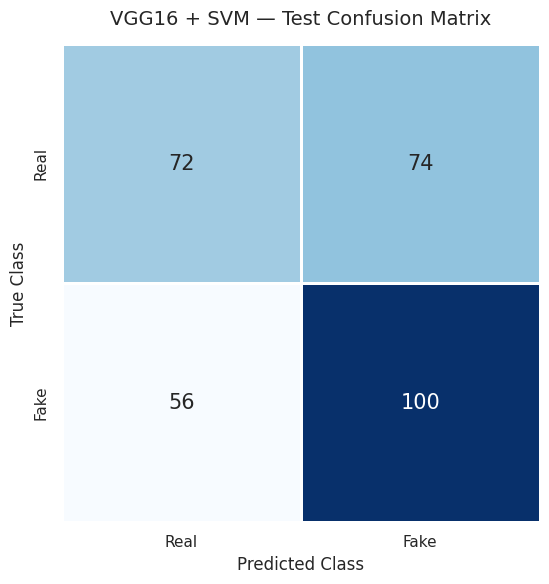

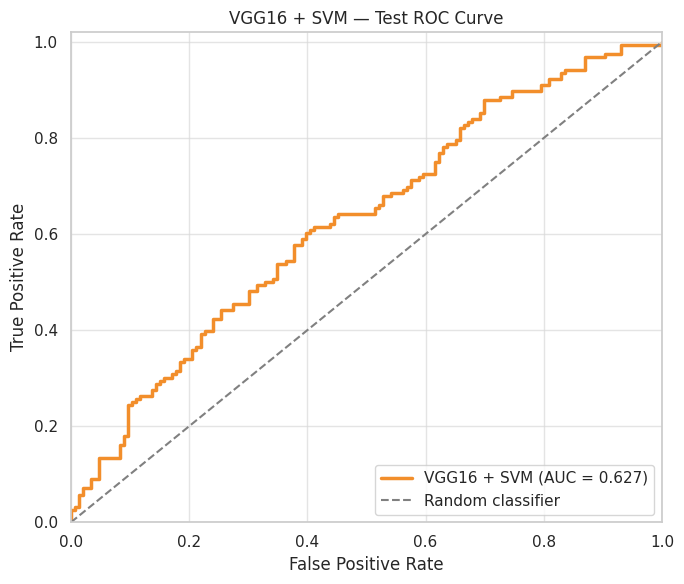

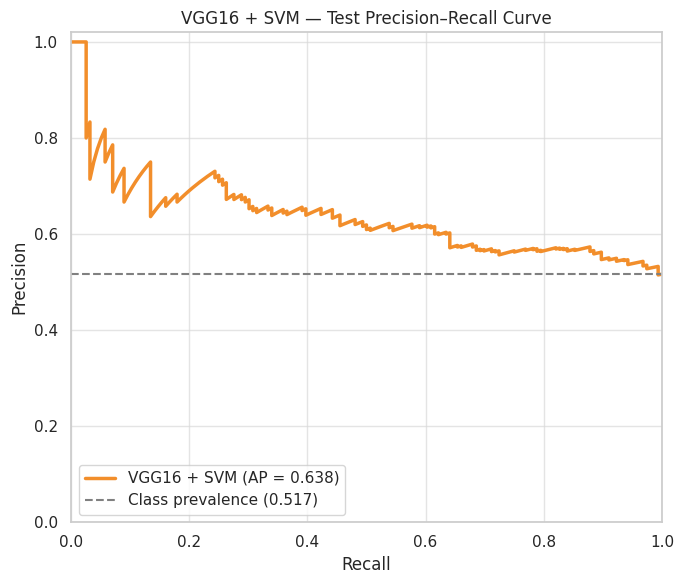

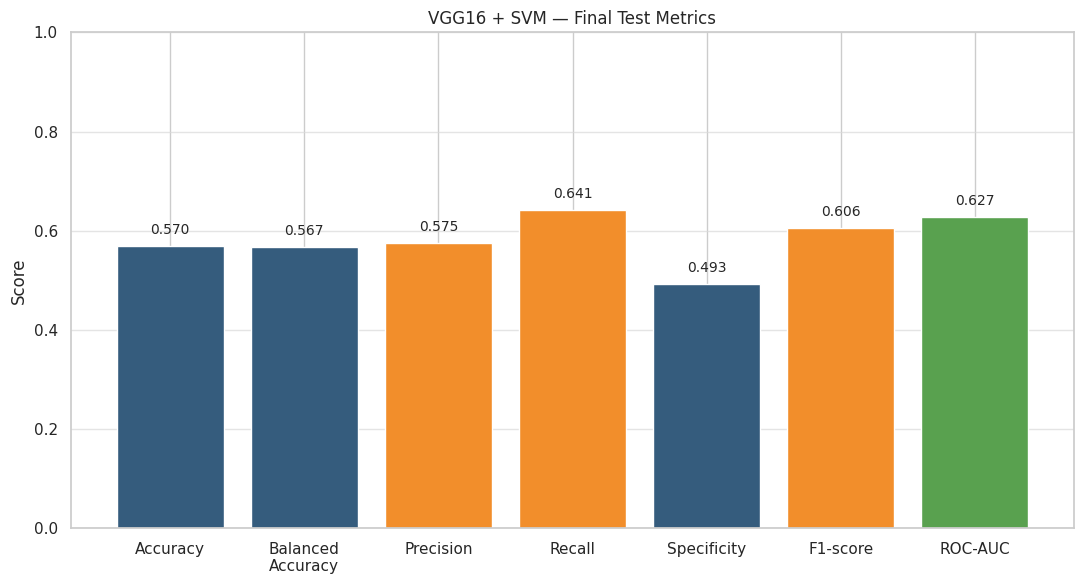


Kaydedilen grafikler:
 - confusion_matrix_600dpi.png (166.8 KB)
 - confusion_matrix.pdf (12.7 KB)
 - roc_curve_600dpi.png (324.2 KB)
 - roc_curve.pdf (16.0 KB)
 - precision_recall_curve_600dpi.png (292.7 KB)
 - precision_recall_curve.pdf (16.2 KB)
 - test_metrics_600dpi.png (280.0 KB)
 - test_metrics.pdf (16.3 KB)

✅ 11. HÜCRE TAMAMLANDI — Test grafikleri PNG 600 DPI ve PDF olarak kaydedildi.


In [22]:
# ============================================================
# 11) TEST GRAFİKLERİ — 600 DPI
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve
)

print("=" * 80)
print("FINAL TEST FIGURES — 600 DPI")
print("=" * 80)

FIGURES_DIR = Path(
    globals().get(
        "FIGURES_DIR",
        Path(OUTPUT_DIR) / "figures"
    )
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Tüm ağız modellerinde kullanılabilecek ortak renkler
REAL_COLOR = "#355C7D"
FAKE_COLOR = "#F28E2B"
GRID_COLOR = "#D9D9D9"

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

saved_figure_files = []

# ------------------------------------------------------------
# 1. Confusion Matrix
# ------------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(7, 6)
)

sns.heatmap(
    TEST_CONFUSION_MATRIX,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    square=True,
    linewidths=1,
    linecolor="white",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"],
    annot_kws={"size": 15},
    ax=axis
)

axis.set_title(
    "VGG16 + SVM — Test Confusion Matrix",
    fontsize=14,
    pad=14
)
axis.set_xlabel("Predicted Class")
axis.set_ylabel("True Class")

figure.tight_layout()

cm_png = FIGURES_DIR / "confusion_matrix_600dpi.png"
cm_pdf = FIGURES_DIR / "confusion_matrix.pdf"

figure.savefig(
    cm_png,
    dpi=600,
    bbox_inches="tight"
)
figure.savefig(
    cm_pdf,
    bbox_inches="tight"
)

plt.show()
plt.close(figure)

saved_figure_files.extend([cm_png, cm_pdf])

# ------------------------------------------------------------
# 2. ROC Curve
# ------------------------------------------------------------

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    TEST_DECISION_SCORE
)

figure, axis = plt.subplots(
    figsize=(7, 6)
)

axis.plot(
    fpr,
    tpr,
    color=FAKE_COLOR,
    linewidth=2.5,
    label=(
        f"VGG16 + SVM "
        f"(AUC = {test_roc_auc:.3f})"
    )
)

axis.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=1.5,
    label="Random classifier"
)

axis.set_xlim(0, 1)
axis.set_ylim(0, 1.02)
axis.set_xlabel("False Positive Rate")
axis.set_ylabel("True Positive Rate")
axis.set_title("VGG16 + SVM — Test ROC Curve")
axis.legend(loc="lower right")
axis.grid(
    True,
    color=GRID_COLOR,
    alpha=0.7
)

figure.tight_layout()

roc_png = FIGURES_DIR / "roc_curve_600dpi.png"
roc_pdf = FIGURES_DIR / "roc_curve.pdf"

figure.savefig(
    roc_png,
    dpi=600,
    bbox_inches="tight"
)
figure.savefig(
    roc_pdf,
    bbox_inches="tight"
)

plt.show()
plt.close(figure)

saved_figure_files.extend([roc_png, roc_pdf])

# ------------------------------------------------------------
# 3. Precision–Recall Curve
# ------------------------------------------------------------

pr_precision, pr_recall, pr_thresholds = (
    precision_recall_curve(
        y_test,
        TEST_DECISION_SCORE
    )
)

fake_prevalence = float(
    np.mean(y_test == 1)
)

figure, axis = plt.subplots(
    figsize=(7, 6)
)

axis.plot(
    pr_recall,
    pr_precision,
    color=FAKE_COLOR,
    linewidth=2.5,
    label=(
        f"VGG16 + SVM "
        f"(AP = {test_average_precision:.3f})"
    )
)

axis.axhline(
    fake_prevalence,
    linestyle="--",
    color="gray",
    linewidth=1.5,
    label=(
        f"Class prevalence "
        f"({fake_prevalence:.3f})"
    )
)

axis.set_xlim(0, 1)
axis.set_ylim(0, 1.02)
axis.set_xlabel("Recall")
axis.set_ylabel("Precision")
axis.set_title(
    "VGG16 + SVM — Test Precision–Recall Curve"
)
axis.legend(loc="lower left")
axis.grid(
    True,
    color=GRID_COLOR,
    alpha=0.7
)

figure.tight_layout()

pr_png = (
    FIGURES_DIR /
    "precision_recall_curve_600dpi.png"
)
pr_pdf = (
    FIGURES_DIR /
    "precision_recall_curve.pdf"
)

figure.savefig(
    pr_png,
    dpi=600,
    bbox_inches="tight"
)
figure.savefig(
    pr_pdf,
    bbox_inches="tight"
)

plt.show()
plt.close(figure)

saved_figure_files.extend([pr_png, pr_pdf])

# ------------------------------------------------------------
# 4. Test metrikleri çubuk grafiği
# ------------------------------------------------------------

metric_names = [
    "Accuracy",
    "Balanced\nAccuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1-score",
    "ROC-AUC"
]

metric_values = [
    test_accuracy,
    test_balanced_accuracy,
    test_precision,
    test_recall,
    test_specificity,
    test_f1,
    test_roc_auc
]

figure, axis = plt.subplots(
    figsize=(11, 6)
)

bars = axis.bar(
    metric_names,
    metric_values,
    color=[
        REAL_COLOR,
        REAL_COLOR,
        FAKE_COLOR,
        FAKE_COLOR,
        REAL_COLOR,
        FAKE_COLOR,
        "#59A14F"
    ],
    edgecolor="white"
)

axis.set_ylim(0, 1)
axis.set_ylabel("Score")
axis.set_title(
    "VGG16 + SVM — Final Test Metrics"
)
axis.grid(
    axis="y",
    color=GRID_COLOR,
    alpha=0.7
)

for bar, value in zip(
    bars,
    metric_values
):
    axis.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.018,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

figure.tight_layout()

metrics_png = (
    FIGURES_DIR /
    "test_metrics_600dpi.png"
)
metrics_pdf = (
    FIGURES_DIR /
    "test_metrics.pdf"
)

figure.savefig(
    metrics_png,
    dpi=600,
    bbox_inches="tight"
)
figure.savefig(
    metrics_pdf,
    bbox_inches="tight"
)

plt.show()
plt.close(figure)

saved_figure_files.extend([
    metrics_png,
    metrics_pdf
])

# ------------------------------------------------------------
# 5. Dosya kontrolleri
# ------------------------------------------------------------

for figure_file in saved_figure_files:
    assert figure_file.exists()
    assert figure_file.stat().st_size > 0

print("\nKaydedilen grafikler:")

for figure_file in saved_figure_files:
    print(
        " -",
        figure_file.name,
        f"({figure_file.stat().st_size / 1024:.1f} KB)"
    )

print(
    "\n✅ 11. HÜCRE TAMAMLANDI — "
    "Test grafikleri PNG 600 DPI ve PDF olarak kaydedildi."
)

In [23]:
# ============================================================
# 12) DENEY ÖZETİ, ORTAM VE TEKRAR ÜRETİLEBİLİRLİK KAYDI
# ============================================================

import json
import platform
import sys
import numpy as np
import pandas as pd
import sklearn
import tensorflow as tf

from pathlib import Path
from datetime import datetime

print("=" * 80)
print("EXPERIMENT SUMMARY AND REPRODUCIBILITY RECORD")
print("=" * 80)

# ------------------------------------------------------------
# 1. Deney özeti
# ------------------------------------------------------------

experiment_summary = {
    "experiment": {
        "name": "VGG16 Feature Extractor + SVM — Mouth Region",
        "run_id": str(RUN_ID),
        "region": "mouth",
        "task": "binary deepfake classification",
        "classes": {
            "0": "real",
            "1": "fake"
        },
        "seed": int(SEED),
        "execution_device": (
            "GPU"
            if tf.config.list_physical_devices("GPU")
            else "CPU"
        )
    },

    "dataset": {
        "root": str(DATA_DIR),
        "used_image_type": "mouth_roi_png_only",
        "debug_images_used": False,
        "total_samples": 2987,
        "train_samples": 2389,
        "validation_samples": 296,
        "test_samples": 302,
        "class_counts": {
            "train": {
                "real": 1197,
                "fake": 1192
            },
            "validation": {
                "real": 155,
                "fake": 141
            },
            "test": {
                "real": 146,
                "fake": 156
            },
            "total": {
                "real": 1498,
                "fake": 1489
            }
        },
        "duplicate_path_check": "PASS",
        "duplicate_sample_id_check": "PASS",
        "cross_class_filename_check": "PASS",
        "split_overlap_check": "PASS"
    },

    "preprocessing": {
        "color_mode": "RGB",
        "image_size": [224, 224],
        "resize_method": "bilinear",
        "augmentation": False,
        "vgg16_preprocess_input": True,
        "svm_feature_scaling": "StandardScaler",
        "scaler_fit_stage": "train_plus_validation_for_final_model"
    },

    "feature_extractor": {
        "architecture": "VGG16",
        "weights": "ImageNet",
        "include_top": False,
        "pooling": "GlobalAveragePooling2D",
        "trainable": False,
        "output_dimension": 512
    },

    "model_selection": {
        "classifier": "SVC",
        "selection_data": "validation_only",
        "selection_metric": "F1-score",
        "test_used_during_selection": False,
        "candidate_count": 12,
        "kernels": ["linear", "rbf"],
        "linear_C_values": [0.1, 1, 10],
        "rbf_C_values": [1, 10, 100],
        "rbf_gamma_values": [
            "scale",
            0.001,
            0.01
        ],
        "best_parameters": {
            "kernel": str(
                BEST_SVM_PARAMS["kernel"]
            ),
            "C": float(
                BEST_SVM_PARAMS["C"]
            ),
            "gamma": str(
                BEST_SVM_PARAMS["gamma"]
            )
        },
        "best_validation_metrics": {
            "accuracy": float(
                best_row["val_accuracy"]
            ),
            "f1_score": float(
                best_row["val_f1"]
            ),
            "roc_auc": float(
                best_row["val_roc_auc"]
            )
        }
    },

    "final_training": {
        "training_data": "train_plus_validation",
        "training_samples": 2685,
        "test_samples_excluded": 302,
        "class_weight": "balanced",
        "support_vector_count": int(
            support_vector_count
        ),
        "duration_seconds": float(
            final_training_seconds
        )
    },

    "final_test_results": {
        "test_samples": 302,
        "accuracy": float(test_accuracy),
        "balanced_accuracy": float(
            test_balanced_accuracy
        ),
        "precision_fake": float(
            test_precision
        ),
        "recall_fake": float(test_recall),
        "specificity_real": float(
            test_specificity
        ),
        "f1_score_fake": float(test_f1),
        "roc_auc": float(test_roc_auc),
        "average_precision": float(
            test_average_precision
        ),
        "mcc": float(test_mcc),
        "confusion_matrix": {
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp)
        }
    },

    "software_environment": {
        "python": platform.python_version(),
        "tensorflow": tf.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "platform": platform.platform()
    },

    "output": {
        "output_directory": str(OUTPUT_DIR),
        "artifacts_directory": str(
            ARTIFACTS_DIR
        ),
        "models_directory": str(
            MODELS_DIR
        ),
        "figures_directory": str(
            FIGURES_DIR
        )
    },

    "created_at": datetime.now().isoformat(
        timespec="seconds"
    )
}

# ------------------------------------------------------------
# 2. JSON deney özeti
# ------------------------------------------------------------

EXPERIMENT_SUMMARY_FILE = (
    ARTIFACTS_DIR /
    "experiment_summary.json"
)

with open(
    EXPERIMENT_SUMMARY_FILE,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        experiment_summary,
        file,
        ensure_ascii=False,
        indent=2
    )

# ------------------------------------------------------------
# 3. Tek satırlık sonuç tablosu
# ------------------------------------------------------------

FINAL_RESULTS_TABLE_FILE = (
    ARTIFACTS_DIR /
    "final_results_table.csv"
)

final_results_table = pd.DataFrame([{
    "run_id": str(RUN_ID),
    "region": "mouth",
    "feature_extractor": "VGG16_ImageNet_GAP",
    "feature_dimension": 512,
    "classifier": "SVM",
    "kernel": str(
        BEST_SVM_PARAMS["kernel"]
    ),
    "C": float(BEST_SVM_PARAMS["C"]),
    "gamma": str(
        BEST_SVM_PARAMS["gamma"]
    ),
    "total_samples": 2987,
    "train_samples": 2389,
    "validation_samples": 296,
    "test_samples": 302,
    "validation_f1": float(
        best_row["val_f1"]
    ),
    "validation_roc_auc": float(
        best_row["val_roc_auc"]
    ),
    "test_accuracy": float(
        test_accuracy
    ),
    "test_balanced_accuracy": float(
        test_balanced_accuracy
    ),
    "test_precision_fake": float(
        test_precision
    ),
    "test_recall_fake": float(
        test_recall
    ),
    "test_specificity_real": float(
        test_specificity
    ),
    "test_f1_fake": float(test_f1),
    "test_roc_auc": float(test_roc_auc),
    "test_average_precision": float(
        test_average_precision
    ),
    "test_mcc": float(test_mcc),
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp),
    "seed": int(SEED)
}])

final_results_table.to_csv(
    FINAL_RESULTS_TABLE_FILE,
    index=False
)

# ------------------------------------------------------------
# 4. Ortam sürümleri
# ------------------------------------------------------------

ENVIRONMENT_FILE = (
    ARTIFACTS_DIR /
    "environment.txt"
)

environment_lines = [
    f"Python=={platform.python_version()}",
    f"TensorFlow=={tf.__version__}",
    f"NumPy=={np.__version__}",
    f"Pandas=={pd.__version__}",
    f"scikit-learn=={sklearn.__version__}",
    f"Platform={platform.platform()}",
    f"Seed={SEED}",
    (
        "Device="
        + (
            "GPU"
            if tf.config.list_physical_devices("GPU")
            else "CPU"
        )
    )
]

ENVIRONMENT_FILE.write_text(
    "\n".join(environment_lines) + "\n",
    encoding="utf-8"
)

# ------------------------------------------------------------
# 5. İnsan tarafından okunabilir kısa özet
# ------------------------------------------------------------

SUMMARY_TEXT_FILE = (
    ARTIFACTS_DIR /
    "experiment_summary.txt"
)

summary_text = f"""
VGG16 FEATURE EXTRACTOR + SVM — MOUTH REGION
============================================================

Run ID
------
{RUN_ID}

Dataset
-------
Total Mouth ROI : 2987
Train           : 2389
Validation      : 296
Test            : 302
Real total      : 1498
Fake total      : 1489
Debug used      : No

Feature Extractor
-----------------
Architecture     : VGG16
Weights          : ImageNet
Include top      : False
Pooling          : Global Average Pooling
Trainable        : False
Feature dimension: 512
Input size       : 224 x 224 RGB

Final SVM
---------
Kernel           : {BEST_SVM_PARAMS["kernel"]}
C                : {BEST_SVM_PARAMS["C"]}
Gamma            : {BEST_SVM_PARAMS["gamma"]}
Class weight     : balanced
Training data    : train + validation
Test selection   : No

Validation
----------
F1-score         : {float(best_row["val_f1"]):.6f}
ROC-AUC          : {float(best_row["val_roc_auc"]):.6f}
Accuracy         : {float(best_row["val_accuracy"]):.6f}

Final Test
----------
Accuracy          : {test_accuracy:.6f}
Balanced Accuracy : {test_balanced_accuracy:.6f}
Precision (Fake)  : {test_precision:.6f}
Recall (Fake)     : {test_recall:.6f}
Specificity       : {test_specificity:.6f}
F1-score (Fake)   : {test_f1:.6f}
ROC-AUC           : {test_roc_auc:.6f}
Average Precision : {test_average_precision:.6f}
MCC               : {test_mcc:.6f}

Confusion Matrix
----------------
TN={tn}, FP={fp}, FN={fn}, TP={tp}
""".strip()

SUMMARY_TEXT_FILE.write_text(
    summary_text + "\n",
    encoding="utf-8"
)

# ------------------------------------------------------------
# 6. Dosya doğrulamaları
# ------------------------------------------------------------

summary_files = [
    EXPERIMENT_SUMMARY_FILE,
    FINAL_RESULTS_TABLE_FILE,
    ENVIRONMENT_FILE,
    SUMMARY_TEXT_FILE
]

for file_path in summary_files:
    assert file_path.exists()
    assert file_path.stat().st_size > 0

print("\nKaydedilen özet dosyaları:")

for file_path in summary_files:
    print(" -", file_path)

print("\nFinal sonuç tablosu:")
display(final_results_table)

print(
    "\n✅ 12. HÜCRE TAMAMLANDI — "
    "Deney, sonuç ve ortam kayıtları hazır."
)

EXPERIMENT SUMMARY AND REPRODUCIBILITY RECORD

Kaydedilen özet dosyaları:
 - /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçlar/20260808_1240_mouth_vgg16_svm_seed42/artifacts/experiment_summary.json
 - /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçlar/20260808_1240_mouth_vgg16_svm_seed42/artifacts/final_results_table.csv
 - /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçlar/20260808_1240_mouth_vgg16_svm_seed42/artifacts/environment.txt
 - /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçlar/20260808_1240_mouth_vgg16_svm_seed42/artifacts/experiment_summary.txt

Final sonuç tablosu:


,run_id,region,feature_extractor,feature_dimension,classifier,kernel,C,gamma,total_samples,train_samples,...,test_specificity_real,test_f1_fake,test_roc_auc,test_average_precision,test_mcc,tn,fp,fn,tp,seed
0,20260808_1240_mouth_vgg16_svm_seed42,mouth,VGG16_ImageNet_GAP,512,SVM,linear,0.1,scale,2987,2389,...,0.493151,0.606061,0.626932,0.637725,0.135686,72,74,56,100,42



✅ 12. HÜCRE TAMAMLANDI — Deney, sonuç ve ortam kayıtları hazır.


In [24]:
# ============================================================
# 13) DOSYA MANİFESTİ VE SHA-256 BÜTÜNLÜK KONTROLÜ
# ============================================================

import json
import hashlib
import pandas as pd

from pathlib import Path
from datetime import datetime

print("=" * 80)
print("ARTIFACT MANIFEST AND SHA-256 VERIFICATION")
print("=" * 80)

OUTPUT_DIR = Path(OUTPUT_DIR)

MANIFEST_CSV_FILE = (
    ARTIFACTS_DIR /
    "artifact_manifest.csv"
)

MANIFEST_JSON_FILE = (
    ARTIFACTS_DIR /
    "artifact_manifest.json"
)

# ------------------------------------------------------------
# 1. SHA-256 fonksiyonu
# ------------------------------------------------------------

def calculate_sha256(
    file_path: Path,
    chunk_size: int = 1024 * 1024
) -> str:
    sha256 = hashlib.sha256()

    with file_path.open("rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            sha256.update(chunk)

    return sha256.hexdigest()

# ------------------------------------------------------------
# 2. Önceki manifest ve ZIP dosyalarını hariç tut
# ------------------------------------------------------------

excluded_names = {
    MANIFEST_CSV_FILE.name,
    MANIFEST_JSON_FILE.name
}

all_output_files = sorted([
    path
    for path in OUTPUT_DIR.rglob("*")
    if (
        path.is_file()
        and path.name not in excluded_names
        and path.suffix.lower() != ".zip"
    )
])

assert len(all_output_files) > 0, (
    "Çıktı klasöründe dosya bulunamadı."
)

print("Manifest kapsamındaki dosya:", len(all_output_files))

# ------------------------------------------------------------
# 3. Dosya bilgilerini ve hash değerlerini oluştur
# ------------------------------------------------------------

manifest_records = []

for index, file_path in enumerate(
    all_output_files,
    start=1
):
    relative_path = file_path.relative_to(
        OUTPUT_DIR
    )

    file_size = file_path.stat().st_size

    manifest_records.append({
        "relative_path": relative_path.as_posix(),
        "category": relative_path.parts[0],
        "file_name": file_path.name,
        "extension": (
            file_path.suffix.lower()
            if file_path.suffix
            else "none"
        ),
        "size_bytes": int(file_size),
        "size_kb": round(
            file_size / 1024,
            3
        ),
        "sha256": calculate_sha256(file_path)
    })

    if (
        index % 25 == 0
        or index == len(all_output_files)
    ):
        print(
            f"Hash kontrolü: "
            f"{index}/{len(all_output_files)}"
        )

manifest_df = pd.DataFrame(
    manifest_records
).sort_values(
    "relative_path"
).reset_index(drop=True)

# ------------------------------------------------------------
# 4. Temel dosyaların varlığını kontrol et
# ------------------------------------------------------------

required_relative_files = [
    "artifacts/dataset_inventory.csv",
    "artifacts/svm_validation_search_results.csv",
    "artifacts/best_svm_validation_selection.json",
    "artifacts/final_training_summary.json",
    "artifacts/final_test_metrics.json",
    "artifacts/test_predictions.csv",
    "artifacts/classification_report.csv",
    "artifacts/classification_report.txt",
    "artifacts/confusion_matrix.csv",
    "artifacts/final_results_table.csv",
    "artifacts/experiment_summary.json",
    "artifacts/experiment_summary.txt",
    "artifacts/environment.txt",
    "models/final_vgg16_svm_pipeline.joblib",
    "models/final_standard_scaler.joblib",
    "models/final_svm_classifier.joblib",
    "figures/confusion_matrix_600dpi.png",
    "figures/roc_curve_600dpi.png",
    "figures/precision_recall_curve_600dpi.png",
    "figures/test_metrics_600dpi.png"
]

manifest_paths = set(
    manifest_df["relative_path"].tolist()
)

missing_required_files = [
    relative_path
    for relative_path in required_relative_files
    if relative_path not in manifest_paths
]

if missing_required_files:
    raise RuntimeError(
        "Eksik zorunlu çıktı dosyaları:\n- "
        + "\n- ".join(missing_required_files)
    )

# Hash ve boyut kontrolleri
assert (
    manifest_df["size_bytes"] > 0
).all(), "Boş çıktı dosyası bulundu."

assert (
    manifest_df["sha256"].str.len() == 64
).all(), "Geçersiz SHA-256 değeri bulundu."

assert manifest_df[
    "relative_path"
].is_unique, "Manifest yolları tekil değil."

# ------------------------------------------------------------
# 5. Manifest dosyalarını kaydet
# ------------------------------------------------------------

manifest_df.to_csv(
    MANIFEST_CSV_FILE,
    index=False
)

manifest_summary = {
    "run_id": str(RUN_ID),
    "output_directory": str(OUTPUT_DIR),
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "hash_algorithm": "SHA-256",
    "total_files": int(len(manifest_df)),
    "total_size_bytes": int(
        manifest_df["size_bytes"].sum()
    ),
    "total_size_mb": round(
        manifest_df["size_bytes"].sum()
        / (1024 ** 2),
        3
    ),
    "required_file_count": len(
        required_relative_files
    ),
    "missing_required_files": (
        missing_required_files
    ),
    "required_files_check": "PASS",
    "empty_file_check": "PASS",
    "unique_relative_path_check": "PASS",
    "files": manifest_records
}

with open(
    MANIFEST_JSON_FILE,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        manifest_summary,
        file,
        ensure_ascii=False,
        indent=2
    )

# ------------------------------------------------------------
# 6. Son kontroller ve özet
# ------------------------------------------------------------

assert MANIFEST_CSV_FILE.exists()
assert MANIFEST_JSON_FILE.exists()
assert MANIFEST_CSV_FILE.stat().st_size > 0
assert MANIFEST_JSON_FILE.stat().st_size > 0

category_summary = (
    manifest_df.groupby("category")
    .agg(
        file_count=("relative_path", "count"),
        total_size_mb=(
            "size_bytes",
            lambda values: round(
                values.sum() / (1024 ** 2),
                3
            )
        )
    )
    .reset_index()
)

print("\nKategori özeti:")
display(category_summary)

print(
    "Toplam dosya :",
    len(manifest_df)
)
print(
    "Toplam boyut :",
    f"{manifest_summary['total_size_mb']:.3f} MB"
)
print(
    "Zorunlu dosya kontrolü:",
    "PASS"
)
print("\nCSV manifest :", MANIFEST_CSV_FILE)
print("JSON manifest:", MANIFEST_JSON_FILE)

print(
    "\n✅ 13. HÜCRE TAMAMLANDI — "
    "Dosya manifesti ve SHA-256 kontrolleri hazır."
)

ARTIFACT MANIFEST AND SHA-256 VERIFICATION
Manifest kapsamındaki dosya: 129
Hash kontrolü: 25/129
Hash kontrolü: 50/129
Hash kontrolü: 75/129
Hash kontrolü: 100/129
Hash kontrolü: 125/129
Hash kontrolü: 129/129

Kategori özeti:


,category,file_count,total_size_mb
0,artifacts,115,8.485
1,config_resolved.yaml,1,0.001
2,figures,8,1.098
3,logs,1,0.002
4,models,4,17.827


Toplam dosya : 129
Toplam boyut : 27.413 MB
Zorunlu dosya kontrolü: PASS

CSV manifest : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçlar/20260808_1240_mouth_vgg16_svm_seed42/artifacts/artifact_manifest.csv
JSON manifest: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçlar/20260808_1240_mouth_vgg16_svm_seed42/artifacts/artifact_manifest.json

✅ 13. HÜCRE TAMAMLANDI — Dosya manifesti ve SHA-256 kontrolleri hazır.


In [25]:
# ============================================================
# 14) NİHAİ DENEY DOĞRULAMA VE MODELİ YENİDEN YÜKLEME TESTİ
# ============================================================

import json
import joblib
import numpy as np
import pandas as pd

from pathlib import Path
from datetime import datetime
from PIL import Image

print("=" * 80)
print("FINAL EXPERIMENT VALIDATION")
print("=" * 80)

validation_checks = {}

# ------------------------------------------------------------
# 1. Final modeli Drive'dan yeniden yükle
# ------------------------------------------------------------

assert FINAL_MODEL_FILE.exists(), (
    f"Final model bulunamadı: {FINAL_MODEL_FILE}"
)

reloaded_final_pipeline = joblib.load(
    FINAL_MODEL_FILE
)

reloaded_prediction = (
    reloaded_final_pipeline.predict(
        X_test
    ).astype(np.int64)
)

reloaded_decision_score = (
    reloaded_final_pipeline.decision_function(
        X_test
    )
)

prediction_match = np.array_equal(
    reloaded_prediction,
    TEST_PREDICTION
)

score_match = np.allclose(
    reloaded_decision_score,
    TEST_DECISION_SCORE,
    rtol=1e-10,
    atol=1e-10
)

assert prediction_match, (
    "Yeniden yüklenen modelin tahminleri değişti."
)

assert score_match, (
    "Yeniden yüklenen modelin karar skorları değişti."
)

validation_checks[
    "reloaded_model_prediction_match"
] = "PASS"

validation_checks[
    "reloaded_model_score_match"
] = "PASS"

print("✅ Model yeniden yükleme testi: PASS")
print("✅ Tahmin eşitliği testi       : PASS")
print("✅ Karar skoru eşitliği        : PASS")

# ------------------------------------------------------------
# 2. Veri envanteri kontrolleri
# ------------------------------------------------------------

inventory_check_df = pd.read_csv(
    ARTIFACTS_DIR /
    "dataset_inventory.csv"
)

assert len(inventory_check_df) == 2987
assert inventory_check_df[
    "sample_id"
].is_unique

inventory_path_column = next(
    (
        column for column in [
            "image_path",
            "resolved_mouth_path",
            "mouth_path",
            "path"
        ]
        if column in inventory_check_df.columns
    ),
    None
)

assert inventory_path_column is not None

assert inventory_check_df[
    inventory_path_column
].astype(str).is_unique

inventory_paths_lower = (
    inventory_check_df[
        inventory_path_column
    ]
    .astype(str)
    .str.replace("\\", "/", regex=False)
    .str.lower()
)

assert inventory_paths_lower.str.contains(
    "/mouth/"
).all()

assert not inventory_paths_lower.str.contains(
    "/debug/"
).any()

validation_checks[
    "dataset_inventory_count_2987"
] = "PASS"

validation_checks[
    "mouth_only_paths"
] = "PASS"

validation_checks[
    "debug_images_excluded"
] = "PASS"

print("✅ Envanter örnek sayısı        : 2987")
print("✅ Yalnızca mouth ROI kontrolü  : PASS")
print("✅ Debug görüntüsü dışlama      : PASS")

# ------------------------------------------------------------
# 3. Split ve sınıf dağılımı
# ------------------------------------------------------------

class_column = next(
    (
        column for column in [
            "class_name",
            "label"
        ]
        if column in inventory_check_df.columns
    ),
    None
)

assert class_column is not None
assert "split" in inventory_check_df.columns

actual_distribution = (
    inventory_check_df.groupby(
        ["split", class_column]
    )
    .size()
    .to_dict()
)

expected_distribution = {
    ("train", "real"): 1197,
    ("train", "fake"): 1192,
    ("val", "real"): 155,
    ("val", "fake"): 141,
    ("test", "real"): 146,
    ("test", "fake"): 156
}

for key, expected_count in (
    expected_distribution.items()
):
    actual_count = int(
        actual_distribution.get(key, -1)
    )

    assert actual_count == expected_count, (
        f"{key} sayısı hatalı: "
        f"{actual_count} != {expected_count}"
    )

validation_checks[
    "split_class_distribution"
] = "PASS"

print("✅ Split ve sınıf dağılımı      : PASS")

# ------------------------------------------------------------
# 4. Tahmin CSV ve metrik tutarlılığı
# ------------------------------------------------------------

saved_predictions_df = pd.read_csv(
    TEST_PREDICTIONS_FILE
)

assert len(saved_predictions_df) == 302

assert np.array_equal(
    saved_predictions_df[
        "true_label_id"
    ].to_numpy(dtype=np.int64),
    y_test
)

assert np.array_equal(
    saved_predictions_df[
        "predicted_label_id"
    ].to_numpy(dtype=np.int64),
    TEST_PREDICTION
)

assert np.allclose(
    saved_predictions_df[
        "decision_score_fake"
    ].to_numpy(dtype=float),
    TEST_DECISION_SCORE
)

with open(
    TEST_METRICS_FILE,
    "r",
    encoding="utf-8"
) as file:
    saved_metrics = json.load(file)

assert np.isclose(
    saved_metrics["accuracy"],
    test_accuracy
)

assert np.isclose(
    saved_metrics["f1_score"],
    test_f1
)

assert np.isclose(
    saved_metrics["roc_auc"],
    test_roc_auc
)

saved_cm = saved_metrics[
    "confusion_matrix"
]

assert saved_cm["true_negative"] == int(tn)
assert saved_cm["false_positive"] == int(fp)
assert saved_cm["false_negative"] == int(fn)
assert saved_cm["true_positive"] == int(tp)

validation_checks[
    "test_prediction_count_302"
] = "PASS"

validation_checks[
    "saved_predictions_match"
] = "PASS"

validation_checks[
    "saved_metrics_match"
] = "PASS"

print("✅ 302 test tahmini kontrolü    : PASS")
print("✅ Kayıtlı tahmin tutarlılığı   : PASS")
print("✅ Kayıtlı metrik tutarlılığı   : PASS")

# ------------------------------------------------------------
# 5. Grafik dosyaları ve DPI kontrolü
# ------------------------------------------------------------

required_png_figures = [
    FIGURES_DIR /
    "confusion_matrix_600dpi.png",
    FIGURES_DIR /
    "roc_curve_600dpi.png",
    FIGURES_DIR /
    "precision_recall_curve_600dpi.png",
    FIGURES_DIR /
    "test_metrics_600dpi.png"
]

figure_validation_records = []

for figure_path in required_png_figures:
    assert figure_path.exists()
    assert figure_path.stat().st_size > 0

    with Image.open(figure_path) as image:
        dpi = image.info.get(
            "dpi",
            (0, 0)
        )

        dpi_x = float(dpi[0])
        dpi_y = float(dpi[1])

        # PNG kayıtlarında 600 değeri 599.998
        # biçiminde okunabilir.
        assert dpi_x >= 590
        assert dpi_y >= 590

        figure_validation_records.append({
            "file": figure_path.name,
            "width_px": int(image.width),
            "height_px": int(image.height),
            "dpi_x": dpi_x,
            "dpi_y": dpi_y,
            "status": "PASS"
        })

validation_checks[
    "required_600dpi_figures"
] = "PASS"

print("✅ 600 DPI grafik kontrolü      : PASS")

# ------------------------------------------------------------
# 6. Nihai doğrulama raporunu kaydet
# ------------------------------------------------------------

FINAL_VALIDATION_FILE = (
    ARTIFACTS_DIR /
    "final_validation_report.json"
)

final_validation_report = {
    "run_id": str(RUN_ID),
    "validation_time": datetime.now().isoformat(
        timespec="seconds"
    ),
    "overall_status": "PASS",
    "checks": validation_checks,
    "validated_counts": {
        "total_samples": 2987,
        "train_samples": 2389,
        "validation_samples": 296,
        "test_samples": 302,
        "feature_dimension": 512,
        "test_prediction_count": 302
    },
    "final_test_metrics": {
        "accuracy": float(test_accuracy),
        "f1_score": float(test_f1),
        "roc_auc": float(test_roc_auc)
    },
    "figure_validation": (
        figure_validation_records
    )
}

with open(
    FINAL_VALIDATION_FILE,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        final_validation_report,
        file,
        ensure_ascii=False,
        indent=2
    )

assert FINAL_VALIDATION_FILE.exists()
assert FINAL_VALIDATION_FILE.stat().st_size > 0

# Sonraki hücrede kullanılacak durum
FINAL_VALIDATION_STATUS = "PASS"

print("\n" + "=" * 80)
print("FINAL VALIDATION SUMMARY")
print("=" * 80)

for check_name, status in (
    validation_checks.items()
):
    print(
        f"{check_name:<40}: {status}"
    )

print("\nGenel doğrulama sonucu: PASS")
print("Doğrulama raporu:", FINAL_VALIDATION_FILE)

print(
    "\n✅ 14. HÜCRE TAMAMLANDI — "
    "Deney ve bütün nihai çıktılar doğrulandı."
)

FINAL EXPERIMENT VALIDATION
✅ Model yeniden yükleme testi: PASS
✅ Tahmin eşitliği testi       : PASS
✅ Karar skoru eşitliği        : PASS
✅ Envanter örnek sayısı        : 2987
✅ Yalnızca mouth ROI kontrolü  : PASS
✅ Debug görüntüsü dışlama      : PASS
✅ Split ve sınıf dağılımı      : PASS
✅ 302 test tahmini kontrolü    : PASS
✅ Kayıtlı tahmin tutarlılığı   : PASS
✅ Kayıtlı metrik tutarlılığı   : PASS
✅ 600 DPI grafik kontrolü      : PASS

FINAL VALIDATION SUMMARY
reloaded_model_prediction_match         : PASS
reloaded_model_score_match              : PASS
dataset_inventory_count_2987            : PASS
mouth_only_paths                        : PASS
debug_images_excluded                   : PASS
split_class_distribution                : PASS
test_prediction_count_302               : PASS
saved_predictions_match                 : PASS
saved_metrics_match                     : PASS
required_600dpi_figures                 : PASS

Genel doğrulama sonucu: PASS
Doğrulama raporu: /content/drive

In [26]:
# ============================================================
# 15) SON MANİFEST GÜNCELLEMESİ + ZIP ARŞİVİ
# ============================================================

import json
import shutil
import hashlib
import zipfile
import pandas as pd

from pathlib import Path
from datetime import datetime

print("=" * 80)
print("FINAL ARCHIVE CREATION AND VERIFICATION")
print("=" * 80)

if globals().get(
    "FINAL_VALIDATION_STATUS"
) != "PASS":
    raise RuntimeError(
        "Nihai doğrulama PASS değil. "
        "Önce 14. hücreyi çalıştır."
    )

OUTPUT_DIR = Path(OUTPUT_DIR)
RESULTS_ROOT = Path(RESULTS_ROOT)

# ------------------------------------------------------------
# 1. Kısa teslim README dosyası
# ------------------------------------------------------------

FINAL_README_FILE = (
    OUTPUT_DIR /
    "README_FINAL.txt"
)

final_readme_text = f"""
VGG16 FEATURE EXTRACTOR + SVM — MOUTH REGION
============================================================

Run ID: {RUN_ID}
Status: COMPLETED AND VALIDATED

DATASET
-------
Total Mouth ROI : 2987
Train           : 2389
Validation      : 296
Test            : 302
Debug used      : No

MODEL
-----
Feature extractor : VGG16 ImageNet
Include top       : False
Pooling           : Global Average Pooling
Feature dimension : 512
Classifier        : Linear SVM
C                 : 0.1
Class weight      : Balanced
Seed              : 42

FINAL TEST RESULTS
------------------
Accuracy          : {test_accuracy:.6f}
Balanced Accuracy : {test_balanced_accuracy:.6f}
Precision (Fake)  : {test_precision:.6f}
Recall (Fake)     : {test_recall:.6f}
Specificity       : {test_specificity:.6f}
F1-score (Fake)   : {test_f1:.6f}
ROC-AUC           : {test_roc_auc:.6f}
Average Precision : {test_average_precision:.6f}
MCC               : {test_mcc:.6f}

CONFUSION MATRIX
----------------
TN={tn}, FP={fp}, FN={fn}, TP={tp}

VALIDATION
----------
Model reload test        : PASS
Prediction equality      : PASS
Decision-score equality  : PASS
Mouth-only dataset       : PASS
Debug exclusion          : PASS
Split/class distribution : PASS
302 test predictions     : PASS
600 DPI figures          : PASS

OUTPUT CONTENTS
---------------
artifacts/ : Metrics, predictions, summaries and manifests
models/    : Final pipeline, scaler and SVM classifier
figures/   : 600 DPI PNG and PDF figures
logs/      : Experiment log

Overall status: PASS
""".strip()

FINAL_README_FILE.write_text(
    final_readme_text + "\n",
    encoding="utf-8"
)

# ------------------------------------------------------------
# 2. Manifesti son dosyalarla yeniden oluştur
# ------------------------------------------------------------

def final_sha256(
    file_path: Path,
    chunk_size: int = 1024 * 1024
) -> str:
    hash_object = hashlib.sha256()

    with file_path.open("rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            hash_object.update(chunk)

    return hash_object.hexdigest()

MANIFEST_CSV_FILE = (
    ARTIFACTS_DIR /
    "artifact_manifest.csv"
)

MANIFEST_JSON_FILE = (
    ARTIFACTS_DIR /
    "artifact_manifest.json"
)

excluded_manifest_names = {
    MANIFEST_CSV_FILE.name,
    MANIFEST_JSON_FILE.name
}

final_output_files = sorted([
    path
    for path in OUTPUT_DIR.rglob("*")
    if (
        path.is_file()
        and path.name
        not in excluded_manifest_names
        and path.suffix.lower() != ".zip"
    )
])

final_manifest_records = []

for file_path in final_output_files:
    relative_path = file_path.relative_to(
        OUTPUT_DIR
    )

    file_size = file_path.stat().st_size

    final_manifest_records.append({
        "relative_path": relative_path.as_posix(),
        "category": relative_path.parts[0],
        "file_name": file_path.name,
        "extension": (
            file_path.suffix.lower()
            if file_path.suffix
            else "none"
        ),
        "size_bytes": int(file_size),
        "size_kb": round(
            file_size / 1024,
            3
        ),
        "sha256": final_sha256(file_path)
    })

final_manifest_df = pd.DataFrame(
    final_manifest_records
).sort_values(
    "relative_path"
).reset_index(drop=True)

assert (
    "artifacts/final_validation_report.json"
    in set(final_manifest_df["relative_path"])
)

assert (
    "README_FINAL.txt"
    in set(final_manifest_df["relative_path"])
)

assert (
    final_manifest_df["size_bytes"] > 0
).all()

assert (
    final_manifest_df["sha256"].str.len() == 64
).all()

final_manifest_df.to_csv(
    MANIFEST_CSV_FILE,
    index=False
)

final_manifest_json = {
    "run_id": str(RUN_ID),
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "hash_algorithm": "SHA-256",
    "overall_validation_status": "PASS",
    "total_manifested_files": int(
        len(final_manifest_df)
    ),
    "total_manifested_size_bytes": int(
        final_manifest_df["size_bytes"].sum()
    ),
    "files": final_manifest_records
}

with open(
    MANIFEST_JSON_FILE,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        final_manifest_json,
        file,
        ensure_ascii=False,
        indent=2
    )

print(
    "Güncel manifest dosya sayısı:",
    len(final_manifest_df)
)

# ------------------------------------------------------------
# 3. ZIP arşivini oluştur
# ------------------------------------------------------------

archive_base_path = (
    RESULTS_ROOT /
    str(RUN_ID)
)

FINAL_ZIP_FILE = Path(
    str(archive_base_path) + ".zip"
)

# Aynı isimli eski ZIP varsa make_archive
# yeni doğrulanmış arşivle günceller.
created_archive_path = shutil.make_archive(
    base_name=str(archive_base_path),
    format="zip",
    root_dir=str(OUTPUT_DIR.parent),
    base_dir=OUTPUT_DIR.name
)

FINAL_ZIP_FILE = Path(
    created_archive_path
)

assert FINAL_ZIP_FILE.exists()
assert FINAL_ZIP_FILE.stat().st_size > 0

# ------------------------------------------------------------
# 4. ZIP bütünlük testi
# ------------------------------------------------------------

with zipfile.ZipFile(
    FINAL_ZIP_FILE,
    mode="r"
) as zip_file:
    corrupted_file = zip_file.testzip()

    if corrupted_file is not None:
        raise RuntimeError(
            "ZIP içinde bozuk dosya bulundu: "
            + corrupted_file
        )

    zip_members = zip_file.namelist()

required_zip_members = [
    f"{RUN_ID}/README_FINAL.txt",
    (
        f"{RUN_ID}/artifacts/"
        "final_validation_report.json"
    ),
    (
        f"{RUN_ID}/artifacts/"
        "final_test_metrics.json"
    ),
    (
        f"{RUN_ID}/artifacts/"
        "test_predictions.csv"
    ),
    (
        f"{RUN_ID}/artifacts/"
        "artifact_manifest.csv"
    ),
    (
        f"{RUN_ID}/models/"
        "final_vgg16_svm_pipeline.joblib"
    ),
    (
        f"{RUN_ID}/figures/"
        "confusion_matrix_600dpi.png"
    ),
    (
        f"{RUN_ID}/figures/"
        "roc_curve_600dpi.png"
    )
]

missing_zip_members = [
    member
    for member in required_zip_members
    if member not in zip_members
]

if missing_zip_members:
    raise RuntimeError(
        "ZIP içinde eksik zorunlu dosyalar:\n- "
        + "\n- ".join(missing_zip_members)
    )

# ------------------------------------------------------------
# 5. ZIP SHA-256 değerini kaydet
# ------------------------------------------------------------

FINAL_ZIP_SHA256 = final_sha256(
    FINAL_ZIP_FILE
)

ZIP_SHA256_FILE = Path(
    str(FINAL_ZIP_FILE) + ".sha256"
)

ZIP_SHA256_FILE.write_text(
    f"{FINAL_ZIP_SHA256}  "
    f"{FINAL_ZIP_FILE.name}\n",
    encoding="utf-8"
)

assert ZIP_SHA256_FILE.exists()

# ------------------------------------------------------------
# 6. Nihai teslim özeti
# ------------------------------------------------------------

zip_size_mb = (
    FINAL_ZIP_FILE.stat().st_size
    / (1024 ** 2)
)

print("\n" + "=" * 80)
print("EXPERIMENT COMPLETED SUCCESSFULLY")
print("=" * 80)

print("Run ID           :", RUN_ID)
print("Doğrulama        : PASS")
print("Manifest dosyası :", len(final_manifest_df))
print("ZIP içeriği      :", len(zip_members), "öğe")
print("ZIP boyutu       :", f"{zip_size_mb:.3f} MB")
print("ZIP SHA-256      :", FINAL_ZIP_SHA256)

print("\nSonuç klasörü:")
print(OUTPUT_DIR)

print("\nTeslim ZIP dosyası:")
print(FINAL_ZIP_FILE)

print("\nSHA-256 dosyası:")
print(ZIP_SHA256_FILE)

print(
    "\n✅ 15. HÜCRE TAMAMLANDI — "
    "VGG16 + SVM ağız bölgesi deneyi tamamlandı, "
    "doğrulandı ve ZIP olarak arşivlendi."
)

FINAL ARCHIVE CREATION AND VERIFICATION
Güncel manifest dosya sayısı: 131

EXPERIMENT COMPLETED SUCCESSFULLY
Run ID           : 20260808_1240_mouth_vgg16_svm_seed42
Doğrulama        : PASS
Manifest dosyası : 131
ZIP içeriği      : 145 öğe
ZIP boyutu       : 12.311 MB
ZIP SHA-256      : e31173b623f71b1484436368ea0400edeaab52211468719d8bb2a08017fa583b

Sonuç klasörü:
/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçlar/20260808_1240_mouth_vgg16_svm_seed42

Teslim ZIP dosyası:
/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçlar/20260808_1240_mouth_vgg16_svm_seed42.zip

SHA-256 dosyası:
/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Dilara/Deney 1/Sonuçlar/20260808_1240_mouth_vgg16_svm_seed42.zip.sha256

✅ 15. HÜCRE TAMAMLANDI — VGG16 + SVM ağız bölgesi deneyi tamamlandı, doğrulandı ve ZIP olarak arşivlendi.
